In [1]:
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [ ]:

# ------------------------------
# Config / toggles
# ------------------------------
SEED = 1
np.random.seed(SEED); torch.manual_seed(SEED)

# Trajectory length and dimensionality
T = 10
D = 2 * T

# Synthetic mixture size (for data generation only)
K = 1

# Number of candidate tubes per scene (the "union of tubes" size k)
NUM_TUBES = 50           # increase for denser coverage; costs scale ~O(n_scenes * NUM_TUBES)

# Scenario and terminal anchoring
# baseline is an easier scenario with increasing variance with 3 modes
# mid_peak is a harder scenario with variance peaking in the middle. there are 3+2 = 5 modes. 
USE_MARGINAL_DATASET = True
SCENARIO = "mid_peak"     # "baseline" or "mid_peak"
ANCHOR_END = (SCENARIO == "mid_peak")
END_SIGMA = np.array([0.008, 0.008])  # anchor std per axis if ANCHOR_END=True

# Teacher + regularization
USE_SCORENET_TEACHER = True           # we use a score network. 
USE_EPSNET_TEACHER = False
SIGMA_MIN = 0.005
SIGMA_MAX = 0.5
SIGMA_EVALS = [0.01]       # probe small σ for sharper curvature[0.005, 0.01, 0.02]
WHITEN = False
CURVATURE_FLOOR = 0.1                   # adds δ·u to HVP target (caps covariance); can be lower, e.g., 0.05

# Calibration settings
per_horizon_calibration = True          # whether to do per-horizon calibration
per_path_calibration = True             # whether to do per-path calibration (not used in paper)

# Numerics (kept from v6 for stability)
WOODBURY_JITTER = 1e-5                  # ε added to (I + R^T A^{-1} R) ; jitter should be around 1e-6 or 1e-5
PRECISION_RIDGE = 1e-7                  # A <- L L^T + λI (prefer this over block ridge); for numerical stability
BLOCK_RIDGE = 0.0                       # optional block ridge on 2x2 marginals
EIGEN_FLOOR = 1e-9                      # PSD floor for 2x2 marginals

# α-grid for calibration
ALPHAS_GRID = np.array([0.50, 0.70, 0.80, 0.90, 0.95])

# Low-rank tail for long-range couplings
USE_LOW_RANK_TAIL = True
RANK_R = 10
LAMBDA_R_SMOOTH = 1e-3
LAMBDA_R_L2     = 3e-4

DEVICE = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")

# Training steps (you can reduce for quick tests)
DSM_STEPS = 40000 # 10000
DSM_BATCH = 512
DSM_LR    = 2e-3

PH_STEPS  = 2000
PH_BATCH  = 128
PH_PROBES = 4
PH_LR     = 3e-3

# Mixture weights (which modes to mix from)
MIX_WEIGHTS = np.array([1], dtype=np.float64) # np.array([0.45, 0.30, 0.25], dtype=np.float64)



In [33]:
# Import stable block marginal extraction from evaluation_utils
from evaluation_utils import block_marginal_from_factors

# Funciton Definitions
# -----------------------------------------------------------------------------
# Prediction-only calibration & evaluation using the UNION approach with PATH
# calibration (tube-consistent): for each scene, we ask whether there exists a
# *single* tube k such that the truth stays inside that tube's per-time ellipses
# for ALL horizons. Calibration proceeds in two stages:
#   (1) Per-horizon UNION calibration via closed-form quantiles:
#       s_t(α) = sqrt( Quantile_α( min_k M2[i,k,t] / τ_α ) )
#       where M2[i,k,t] = (y_true_{i,t} - mu_{i,k,t})^T S_{i,k,t}^{-1} (y_true_{i,t} - mu_{i,k,t}).
#   (2) PATH multiplier γ(α) via closed-form quantiles:
#       γ_req(i;α) = sqrt( min_k max_t ( M2[i,k,t] / s_t(α)^2 ) / τ_α ),
#       γ(α) = Quantile_α( γ_req(i;α) ).
#
# This file removes MPC/policy-specific code; it only evaluates the *set-level*
# "exists tube" semantics for prediction displays.
#
# -----------------------------------------------------------------------------

# ------------------------------
# Synthetic mixture (Gaussian chain + anchor)
# ------------------------------
def process_noise_Q(t_index: int, mode: int) -> np.ndarray:
    if SCENARIO == "baseline":
        base_x = 0.03 + 0.010 * t_index
        base_y = 0.02 + 0.015 * t_index
    elif SCENARIO == "mid_peak":
        center = 0.5 * (T + 1)
        width  = 0.22 * T
        bump   = math.exp(- ((t_index - center) ** 2) / (2.0 * width ** 2))
        base_x = 0.03 + 0.015 * bump
        base_y = 0.03 + 0.020 * bump
    else:
        raise ValueError("Unknown SCENARIO")
    if mode in (1, 2):   # turns → more lateral uncertainty
        base_y *= 1.35
    return np.array([[base_x, 0.0],[0.0, base_y]], dtype=np.float64)

def mean_path(mode: int, T: int, v: float = 0.5, dtheta: float = 0.09) -> np.ndarray:
    x, y, theta = 0.0, 0.0, 0.0; pts = []
    for _ in range(T):
        if mode == 1:   theta += dtheta
        elif mode == 2: theta -= dtheta
        x += v * math.cos(theta); y += v * math.sin(theta)
        pts.append([x, y])
    return np.array(pts, dtype=np.float64).reshape(-1)

def build_mode_parameters(mode: int):
    mu = mean_path(mode, T)
    Q_inv = [np.linalg.inv(process_noise_Q(t, mode)) for t in range(1, T+1)]
    J = np.zeros((D, D), dtype=np.float64)
    for t in range(T):
        if t == 0:      J_block = Q_inv[0] + Q_inv[1]
        elif t == T-1:  J_block = Q_inv[T-1]
        else:           J_block = Q_inv[t] + Q_inv[t+1]
        i = 2*t; J[i:i+2, i:i+2] = J_block
    for t in range(T-1):
        i = 2*t; j = 2*(t+1)
        J[i:i+2, j:j+2] = -Q_inv[t+1]; J[j:j+2, i:i+2] = -Q_inv[t+1]
    eta = J @ mu
    if ANCHOR_END:
        R_end = np.diag(END_SIGMA**2); Rinv = np.linalg.inv(R_end); idx = slice(D-2, D)
        J[idx, idx] = J[idx, idx] + Rinv; eta[idx] = eta[idx] + Rinv @ mu[idx]
    J = 0.5*(J+J.T) + 1e-9*np.eye(D)
    L = np.linalg.cholesky(J)
    m = np.linalg.solve(L.T, np.linalg.solve(L, eta))
    return m, J, L

MODES = [build_mode_parameters(m) for m in range(K)]

def logpdf_mode(y, m, J):
    d = y - m
    return -0.5*float(d @ (J @ d))

def logp_mixture(y_flat):
    vals = [logpdf_mode(y_flat, m, J) + np.log(MIX_WEIGHTS[k]+1e-16)
            for k,(m,J,_L) in enumerate(MODES)]
    m = np.max(vals)
    return m + np.log(np.sum(np.exp(np.array(vals) - m)))

def sample_mode(mode, n):
    m, J, L = MODES[mode]
    X = np.zeros((n, D), dtype=np.float64)
    for i in range(n):
        z = np.random.randn(D); delta = np.linalg.solve(L.T, z)
        X[i] = m + delta
    return X

def sample_mixture(n):
    counts = np.random.multinomial(n, MIX_WEIGHTS)
    chunks = []
    for m in range(K):
        c = counts[m]
        if c>0: chunks.append(sample_mode(m, c))
    X = np.concatenate(chunks, axis=0) if chunks else np.zeros((0,D), dtype=np.float64)
    idx = np.random.permutation(len(X))
    return X[idx], None


# ------------------------------
# Whitening
# ------------------------------

W_VEC = np.ones(D, dtype=np.float64)

def fit_whitener(n_fit=10000):
    global W_VEC
    X, _ = sample_mixture(n_fit)
    std = X.std(axis=0) + 1e-6
    W_VEC = 1.0 / std
    # use 100 to clamp max scaling
    W_VEC = np.clip(W_VEC, None, 100.0)
    print("[WHITEN] median std:", float(np.median(std)), "min:", float(std.min()), "max:", float(std.max()))

def whiten(X): return X * W_VEC

def unwhiten(X): return X / W_VEC
    
def unwhiten_block(S_white, t):
    D_t = np.diag(1.0 / W_VEC[2*t:2*t+2])
    return D_t @ S_white @ D_t


# ------------------------------
# ScoreNet (whitened)
# ------------------------------
class ScoreNet(nn.Module):
    def __init__(self, D, hidden=384):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(D+2, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, D)
        )
    def forward(self, y, sigma):
        log_sig = torch.log(sigma).unsqueeze(1)
        feat = torch.cat([y, log_sig, sigma.unsqueeze(1)], dim=1)
        return self.net(feat)

def train_scorenet():
    model = ScoreNet(D).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DSM_LR)
    Xpool, _ = sample_mixture(25000)
    Xpool = whiten(Xpool) if WHITEN else Xpool
    Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)
    def sample_sigma(batch):
        u = torch.rand(batch, device=DEVICE)
        log_min, log_max = math.log(SIGMA_MIN), math.log(SIGMA_MAX)
        return torch.exp(log_min + u*(log_max - log_min))
    hist = []
    for step in range(1, DSM_STEPS+1):
        idx = np.random.choice(Xpool_t.shape[0], size=DSM_BATCH, replace=False)
        x0 = Xpool_t[idx]; sigma = sample_sigma(x0.shape[0])
        z = torch.randn_like(x0); x = x0 + sigma.view(-1,1)*z
        target = - z / sigma.view(-1,1)
        s_pred = model(x, sigma)
        w = (sigma**2).view(-1,1)
        loss = torch.mean(w * (s_pred - target)**2)
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if step % 250 == 0 or step == DSM_STEPS:
            print(f"[DSM {step:4d}] loss={float(loss.item()):.4e}")
        hist.append(float(loss.item()))
    return model, np.array(hist)

def hvp_from_scorenet(score_net, y_white, sigma_evals, u):
    h_acc = torch.zeros_like(y_white)
    for σ in sigma_evals:
        sigma_eval = torch.full((y_white.shape[0],), fill_value=σ, device=y_white.device, dtype=y_white.dtype)
        y_req = y_white.detach().clone().requires_grad_(True)
        s = score_net(y_req, sigma_eval)
        su = (s * u).sum()
        h = torch.autograd.grad(su, y_req, create_graph=False)[0]
        h_acc = h_acc + h
    h_acc = h_acc / float(len(sigma_evals))
    if CURVATURE_FLOOR > 0.0:
        h_acc = h_acc + float(CURVATURE_FLOOR) * u
    return h_acc


@torch.no_grad()
def sample_from_scorenet(model, n_samples=10, n_steps=500):
    model.eval()
    y = torch.randn(n_samples, T*2, device=DEVICE)

    sigmas = torch.exp(torch.linspace(np.log(SIGMA_MAX), np.log(SIGMA_MIN), n_steps, device=DEVICE))

    for sigma in sigmas:
        sigma_batch = torch.full((n_samples,), sigma, device=DEVICE)
        score = model(y, sigma_batch)

        # ✅ Step size tuned
        epsilon = (sigma**2) * 0.5
        z = torch.randn_like(y, device=DEVICE)
        y = y + epsilon * score + torch.sqrt(2 * epsilon) * z

    y = unwhiten(y.cpu().numpy()) if WHITEN else y.cpu().numpy()
    return y, None  # (n_samples, T*2)



# ------------------------------
# EpsNet (whitened)
# ------------------------------
class EpsNet(nn.Module):
    def __init__(self, D, hidden=384):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(D+2, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, D)
        )
    def forward(self, y, sigma):
        # y: (batch, D), sigma: (batch,)
        log_sig = torch.log(sigma).unsqueeze(1)               # (batch,1)
        feat = torch.cat([y, log_sig, sigma.unsqueeze(1)], 1) # (batch, D+2)
        return self.net(feat)  # predict epsilon (same shape as y)

def train_epsnet(Xpool):
    model = EpsNet(D).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DSM_LR)
    # Xpool, _ = sample_mixture(25000)
    Xpool = whiten(Xpool) if WHITEN else Xpool
    Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)

    def sample_sigma(batch):
        u = torch.rand(batch, device=DEVICE)
        log_min, log_max = math.log(SIGMA_MIN), math.log(SIGMA_MAX)
        return torch.exp(log_min + u*(log_max - log_min))

    hist = []
    for step in range(1, DSM_STEPS+1):
        idx = np.random.choice(Xpool_t.shape[0], size=DSM_BATCH, replace=False)
        x0 = Xpool_t[idx]
        sigma = sample_sigma(x0.size(0))   # (batch,)
        eps = torch.randn_like(x0)         # ground truth ε
        x = x0 + sigma.view(-1,1) * eps    # noisy sample

        eps_hat = model(x, sigma)
        loss = ((eps_hat - eps)**2).mean()

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % 1000 == 0 or step == DSM_STEPS:
            print(f"[EPS {step:4d}] loss={loss.item():.4e}")
        hist.append(loss.item())
    return model, np.array(hist)

'''
hvp if using epsnet
'''
def hvp_from_epsnet(eps_net, y_white, sigma_evals, u):
    h_acc = torch.zeros_like(y_white)
    for σ in sigma_evals:
        sigma_eval = torch.full(
            (y_white.shape[0],), fill_value=σ,
            device=y_white.device, dtype=y_white.dtype
        )
        y_req = y_white.detach().clone().requires_grad_(True)

        # 1. Predict noise
        eps_hat = eps_net(y_req, sigma_eval)

        # 2. Convert noise → score
        s = - eps_hat / sigma_eval.view(-1, *([1] * (y_white.ndim - 1)))
        su = (s * u).sum()
        h = torch.autograd.grad(su, y_req, create_graph=False)[0]
        h_acc = h_acc + h

    # Average across sigmas
    h_acc = h_acc / float(len(sigma_evals))

    # Curvature floor (damping)
    if CURVATURE_FLOOR > 0.0:
        h_acc = h_acc + float(CURVATURE_FLOOR) * u

    return h_acc

@torch.no_grad()
def sample_from_epsnet(model, n_samples=10, n_steps=3000):
    model.eval()
    y = torch.randn(n_samples, T*2, device=DEVICE)

    sigmas = torch.exp(torch.linspace(np.log(SIGMA_MAX), np.log(SIGMA_MIN), n_steps, device=DEVICE))

    for sigma in sigmas:
        sigma_batch = torch.full((n_samples,), sigma, device=DEVICE)
        eps_hat = model(y, sigma_batch)
        score = - eps_hat / sigma_batch.view(-1,1)  # convert noise → score

        # annealed Langevin step
        epsilon = (sigma**2) * 0.5
        z = torch.randn_like(y)
        y = y + epsilon * score + torch.sqrt(2*epsilon) * z

    y = unwhiten(y.cpu().numpy()) if WHITEN else y.cpu().numpy()
    return y, None


# ------------------------------
# Precision head
# ------------------------------
class PrecisionHead(nn.Module):
    def __init__(self, D, T, hidden=220, use_low_rank=False, rank_r=2):
        super().__init__()
        self.D = D; self.T = T; self.use_low_rank = use_low_rank; self.rank_r = rank_r
        self.backbone = nn.Sequential(
            nn.Linear(D, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU()
        )
        self.out_diag = nn.Linear(hidden, 3*T)
        self.out_sub  = nn.Linear(hidden, 4*(T-1)) if T>1 else None
        self.out_R    = nn.Linear(hidden, D*rank_r) if (use_low_rank and rank_r>0) else None
        self.eps = 3e-3
    def forward(self, y):
        B = y.shape[0]
        h = self.backbone(y)
        diag = self.out_diag(h)
        sub  = self.out_sub(h) if self.out_sub is not None else None
        Rmat = self.out_R(h)   if self.out_R   is not None else None
        Ls, Rs = [], []
        for b in range(B):
            L = torch.zeros(self.D, self.D, dtype=y.dtype, device=y.device)
            d = diag[b]
            for t in range(self.T):
                a11 = F.softplus(d[3*t + 0]) + self.eps
                a21 = d[3*t + 1]
                a22 = F.softplus(d[3*t + 2]) + self.eps
                i = 2*t
                L[i+0, i+0] = a11
                L[i+1, i+0] = a21
                L[i+1, i+1] = a22
            if sub is not None:
                s = sub[b]
                for t in range(1, self.T):
                    i = 2*t; j = 2*(t-1)
                    L[i+0, j+0] = s[4*(t-1)+0]
                    L[i+1, j+0] = s[4*(t-1)+1]
                    L[i+0, j+1] = s[4*(t-1)+2]
                    L[i+1, j+1] = s[4*(t-1)+3]
            Ls.append(L)
            if (self.out_R is not None) and (Rmat is not None):
                Rs.append(Rmat[b].view(self.D, self.rank_r))
            else:
                Rs.append(None)
        return Ls, Rs


# ------------------------------
# Train precision head (HVP self-consistency)
# ------------------------------
def temporal_smoothness_penalty(Rb):
    if Rb is None: return 0.0
    r = Rb.shape[1]; loss = 0.0
    for k in range(r):
        col = Rb[:, k].view(T, 2); diff = col[1:] - col[:-1]
        loss += (diff**2).sum()
    return loss / (r * max(1, T-1))

def train_precision_head(teacher=None):
    head = PrecisionHead(D, T, hidden=220, use_low_rank=USE_LOW_RANK_TAIL, rank_r=RANK_R).to(DEVICE)
    opt = torch.optim.Adam(head.parameters(), lr=PH_LR)
    Xpool, _ = sample_mixture(8000)
    Xpool = whiten(Xpool) if WHITEN else Xpool
    Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)
    hist = []
    for step in range(1, PH_STEPS+1):
        idx = np.random.choice(Xpool_t.shape[0], size=PH_BATCH, replace=False)
        yb = Xpool_t[idx]
        L_list, R_list = head(yb)
        loss_prec = 0.0; loss_reg = 0.0
        for _ in range(PH_PROBES):
            u = torch.randn_like(yb)
            if teacher is None:
                raise NotImplementedError("Use ScoreNet teacher under whitening.")
            h = hvp_from_scorenet(teacher, yb, SIGMA_EVALS, u)
            Lu_total = []
            for b in range(yb.shape[0]):
                Lb = L_list[b]; tmp = Lb.t().matmul(u[b]); Au  = Lb.matmul(tmp)
                if USE_LOW_RANK_TAIL and (R_list[b] is not None):
                    Rb = R_list[b]; Au = Au + Rb.matmul(Rb.t().matmul(u[b]))
                Lu_total.append(Au)
            Lu_total = torch.stack(Lu_total, dim=0)
            loss_prec = loss_prec + F.mse_loss(Lu_total + h, torch.zeros_like(h))
        loss_prec = loss_prec / PH_PROBES
        if USE_LOW_RANK_TAIL:
            for b in range(yb.shape[0]):
                Rb = R_list[b]
                if Rb is not None:
                    loss_reg = loss_reg + LAMBDA_R_L2 * (Rb**2).sum() + LAMBDA_R_SMOOTH * temporal_smoothness_penalty(Rb)
        loss = loss_prec + loss_reg
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0)
        opt.step()
        hist.append(float(loss_prec.item()))
        if step % 100 == 0 or step == PH_STEPS:
            print(f"[PH {step:4d}] L_prec={hist[-1]:.4e}  (reg≈{float(loss_reg.item()) if torch.is_tensor(loss_reg) else loss_reg:.2e})")
    return head, np.array(hist)


# ------------------------------
# Candidate generation (diversified union)
# ------------------------------
def generate_scenes(n_scenes, num_tubes, diversify=True, pool_factor=25,
                    diversify_mode: str = "waypoints", waypoint_idxs=None):
    """
    Returns:
      Yp: [n_scenes, num_tubes, D]  candidate trajectories per scene (mixture-only)
      Yt: [n_scenes, D]             ground-truth per scene (mixture draw; independent)
    Diversification is performed *without* using Yt (no leakage):
      - Draw a large pool from the mixture; build features φ per candidate (end-point or waypoints).
      - Greedy farthest-point on φ to pick num_tubes diverse candidates.
    """
    # Ground-truths
    Yt = np.zeros((n_scenes, D), dtype=np.float64)
    for i in range(n_scenes): Yt[i] = sample_mixture(1)[0][0]

    # Default waypoint set
    if diversify_mode == "waypoints" and waypoint_idxs is None:
        waypoint_idxs = [T//3, 2*T//3, T-1]

    # Helper: greedy farthest subset
    def farthest_subset(feat: np.ndarray, m: int) -> list:
        N = feat.shape[0]
        chosen = [int(np.random.randint(N))]
        while len(chosen) < m:
            d2 = np.min([np.sum((feat - feat[j])**2, axis=1) for j in chosen], axis=0)
            d2[chosen] = -1.0
            chosen.append(int(np.argmax(d2)))
        return chosen

    # Candidates per scene
    Yp = np.zeros((n_scenes, num_tubes, D), dtype=np.float64)
    for i in range(n_scenes):
        if not diversify:
            cand, _ = sample_mixture(num_tubes)
            Yp[i] = cand
        else:
            pool_N = max(num_tubes * pool_factor, num_tubes)
            pool, _ = sample_mixture(pool_N)
            traj = pool.reshape(-1, T, 2)
            if diversify_mode == "end":
                feat = traj[:, -1, :]
            elif diversify_mode == "waypoints":
                idxs = [j for j in waypoint_idxs if 0 <= j < T]
                if len(idxs) == 0: idxs = [T-1]
                feat = traj[:, idxs, :].reshape(pool_N, -1)
            else:
                raise ValueError("diversify_mode must be 'end' or 'waypoints'")
            chosen = farthest_subset(feat, num_tubes)
            Yp[i] = pool[chosen]
    return Yp, Yt


# ------------------------------
# Precompute base M2 for union calibration (vectorized + batched)
# ------------------------------
def eval_head_factors_batched(head, Yw_flat, batch=2048):
    """
    Yw_flat: [N*M, D] whitened candidates.
    Returns lists Ls, Rs length N*M of torch tensors (float64).
    """
    head_dtype = next(head.parameters()).dtype if any(True for _ in head.parameters()) else torch.float32
    device = next(head.parameters()).device if any(True for _ in head.parameters()) else torch.device('cpu')
    Ls, Rs = [], []
    with torch.no_grad():
        for i0 in range(0, Yw_flat.shape[0], batch):
            yb = torch.from_numpy(Yw_flat[i0:i0+batch]).to(device=device, dtype=head_dtype)
            L_list, R_list = head(yb)
            # convert to float64 on CPU for numerics
            Ls.extend([L.to(torch.float64).cpu() for L in L_list])
            if USE_LOW_RANK_TAIL and (R_list is not None):
                Rs.extend([(R.to(torch.float64).cpu() if (R is not None) else None) for R in R_list])
            else:
                Rs.extend([None for _ in L_list])
    return Ls, Rs

def precompute_union_m2(head, n_scenes=360, num_tubes=NUM_TUBES, diversify=True,
                        diversify_mode="waypoints", batch=2048):
    """
    Returns:
      Yp: [N,M,D], Yt: [N,D]
      m2: [N,M,T] with M2[i,k,t] = diff^T S^{-1} diff (unwhitened units)
    """
    t0 = time.time()
    Yp, Yt = generate_scenes(n_scenes, num_tubes, diversify=diversify, diversify_mode=diversify_mode)
    # Whiten candidates for the head
    Yp_w = whiten(Yp.reshape(n_scenes, num_tubes, -1)) if WHITEN else Yp
    Yw_flat = Yp_w.reshape(-1, D)
    # Evaluate head in batches
    Ls, Rs = eval_head_factors_batched(head, Yw_flat, batch=batch)
    # For each candidate, extract 2x2 blocks using stable per-timestep extraction
    m2 = np.zeros((n_scenes, num_tubes, T), dtype=np.float64)
    for idx in range(Yw_flat.shape[0]):
        i = idx // num_tubes
        k = idx %  num_tubes
        # Extract 2x2 covariance blocks per timestep (stable method)
        S_blocks_w = np.zeros((T, 2, 2), dtype=np.float64)
        for t in range(T):
            S_t = block_marginal_from_factors(
                Ls[idx], Rs[idx], t,
                eps_M=WOODBURY_JITTER,
                eigen_floor=EIGEN_FLOOR,
                precision_ridge=PRECISION_RIDGE
            ).cpu().numpy()
            S_blocks_w[t] = S_t
        # Unwhiten blocks and invert with eigen clamp
        diffs = Yt[i].reshape(T,2) - Yp[i,k].reshape(T,2)   # unwhitened diffs
        for t in range(T):
            S = unwhiten_block(S_blocks_w[t], t) if WHITEN else S_blocks_w[t]
            w, V = np.linalg.eigh(0.5*(S + S.T))
            w = np.clip(w, EIGEN_FLOOR, None)
            invS = (V * (1.0 / w)) @ V.T
            d = diffs[t]
            m2[i,k,t] = float(d @ (invS @ d))
    t1 = time.time()
    print(f"[PRECOMPUTE] Union m2 computed for {n_scenes} scenes x {num_tubes} tubes in {t1-t0:.2f}s")
    return Yp, Yt, m2


# ------------------------------
# UNION calibration (closed-form via quantiles)
# ------------------------------
def chi2_ppf_df2(alpha: float) -> float:
    return -2.0 * math.log(max(1e-16, 1.0 - float(alpha)))

def calibrate_union_per_horizon_quantile(m2: np.ndarray, alphas=ALPHAS_GRID) -> np.ndarray:
    """
    m2: [N,M,T] base Mahalanobis^2 (unscaled).
    Returns s_table[T, |alphas|] with per-horizon UNION scales via quantiles:
      s_t(α) = sqrt( quantile_α( min_k m2[:, :, t] / τ_α ) )
    """
    N, M, TT = m2.shape
    assert TT == T
    s_table = np.ones((T, len(alphas)), dtype=np.float64)
    Z = m2.min(axis=1)   # [N,T]
    for j, a in enumerate(alphas):
        tau = chi2_ppf_df2(a)
        # For each t, compute the α-quantile of Z[:,t]/tau
        q = np.quantile(Z / tau, a, axis=0, method="linear")
        s_table[:, j] = np.sqrt(np.maximum(q, 1e-16))
    return s_table

def calibrate_union_path_gamma_quantile(m2: np.ndarray, s_table: np.ndarray, alphas=ALPHAS_GRID) -> np.ndarray:
    """
    Given per-horizon s_table, compute γ(α) via closed-form quantiles:
      γ_req(i;α) = sqrt( min_k max_t ( m2[i,k,t] / s_t(α)^2 ) / τ_α )
      γ(α) = quantile_α( γ_req(i;α) ).
    Returns gamma_vec[|alphas|].
    """
    N, M, TT = m2.shape
    assert TT == T
    gamma = np.ones((len(alphas),), dtype=np.float64)
    for j, a in enumerate(alphas):
        tau = chi2_ppf_df2(a)
        s_vec = s_table[:, j]  # [T]
        denom = np.maximum(s_vec**2, 1e-16)
        # max over t, then min over k
        max_over_t = (m2 / denom[np.newaxis, np.newaxis, :]).max(axis=2)    # [N,M]
        min_over_k = max_over_t.min(axis=1)                                  # [N]
        gamma_req = np.sqrt(np.maximum(min_over_k / tau, 0.0))
        gamma[j] = float(np.quantile(gamma_req, a, method="linear"))
    return gamma


# ------------------------------
# UNION evaluation (path event)
# ------------------------------
def evaluate_union_path_from_m2(m2: np.ndarray, s_table: np.ndarray, gamma_vec: np.ndarray, alpha: float) -> float:
    """
    Empirical coverage of the union path event on a given m2 tensor (hold-out recommended):
      cov = (1/N) * |{ i : ∃k, ∀t  m2[i,k,t] / (γ(α)^2 s_t(α)^2) ≤ τ_α }|
    """
    tau = chi2_ppf_df2(alpha)
    # Interpolate s_vec if needed
    # Here alphas are fixed grid; use nearest in grid
    j = int(np.argmin(np.abs(ALPHAS_GRID - alpha)))
    s_vec = s_table[:, j]
    gamma = gamma_vec[j]
    denom = np.maximum((gamma**2) * (s_vec**2), 1e-16)
    max_over_t = (m2 / denom[np.newaxis, np.newaxis, :]).max(axis=2)    # [N,M]
    min_over_k = max_over_t.min(axis=1)                                  # [N]
    cover = float(np.mean(min_over_k <= tau))
    return cover


# ------------------------------
# Plotting helpers (optional visualization)
# ------------------------------
def plot_scene_union_tubes(head, Yp_scene, Yt_scene, alpha=0.90, s_vec=None, gamma=1.0, max_tubes_show=8, title="Union (path) tubes"):
    """
    Visualize up to 'max_tubes_show' tubes for one scene with per-time α-ellipses
    scaled by s_vec and γ.
    """
    Nshow = min(max_tubes_show, Yp_scene.shape[0])
    # Evaluate head for these tubes
    Yw = whiten(Yp_scene[:Nshow]) if WHITEN else Yp_scene[:Nshow]
    Ls, Rs = eval_head_factors_batched(head, Yw, batch=Nshow)
    tau = chi2_ppf_df2(alpha); rad = math.sqrt(tau)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(Yt_scene.reshape(T,2)[:,0], Yt_scene.reshape(T,2)[:,1], 'k--', lw=2, label='truth')
    for k in range(Nshow):
        # Extract 2x2 covariance blocks per timestep (stable method)
        S_blocks_w = np.zeros((T, 2, 2), dtype=np.float64)
        for t in range(T):
            S_t = block_marginal_from_factors(
                Ls[k], Rs[k], t,
                eps_M=WOODBURY_JITTER,
                eigen_floor=EIGEN_FLOOR,
                precision_ridge=PRECISION_RIDGE
            ).cpu().numpy()
            S_blocks_w[t] = S_t
        traj = Yp_scene[k].reshape(T,2)
        ax.plot(traj[:,0], traj[:,1], '-', lw=1.0, alpha=0.7)
        for t in range(T):
            S = unwhiten_block(S_blocks_w[t], t) if WHITEN else S_blocks_w[t]
            scale = (gamma * (s_vec[t] if s_vec is not None else 1.0))**2
            S = scale * S
            w, V = np.linalg.eigh(0.5*(S + S.T)); w = np.clip(w, 1e-12, None)
            width, height = 2*rad*np.sqrt(w[1]), 2*rad*np.sqrt(w[0])
            angle = math.degrees(math.atan2(V[1,1], V[0,1]))
            ctr = traj[t]
            ax.add_patch(Ellipse(ctr, width=width, height=height, angle=angle,
                                 fill=False, linewidth=0.7, alpha=0.7))
    ax.set_title(title); ax.set_aspect('equal','box'); ax.grid(True); ax.legend(); plt.show()

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_scene_union_tubes_raw(
    head,
    Yp_scene,
    Yt_scene=None,
    alpha=0.90,
    max_tubes_show=8,
    num_real_traj=0,
    ellipse_every=1,
    title="Union (path) tubes — RAW (no calibration)"
):
    """
    Visualize up to 'max_tubes_show' tubes for one scene with per-time α-ellipses,
    WITHOUT any calibration scaling (no s_vec, no gamma).

    Args
    ----
    head : trained precision head (supports eval_head_factors_batched)
    Yp_scene : np.ndarray, shape [M, 2T]
        Candidate means for one scene (flattened).
    Yt_scene : np.ndarray or None
        Optional ground-truth flattened trajectory [2T].
    alpha : float
        Coverage level (e.g., 0.90) to set the χ²₂ threshold for ellipses.
    max_tubes_show : int
        Max number of tubes to draw for clarity.
    num_real_traj : int
        Number of sampled trajectories to draw from the mixture (default 0).
    ellipse_every : int
        Draw an ellipse every `ellipse_every` horizons (1 = every t).
    title : str
        Plot title.

    Returns
    -------
    (fig, ax)
    """
    # Select how many tubes to show
    Nshow = min(max_tubes_show, Yp_scene.shape[0])

    # Evaluate the head for these tubes (respect whitening flag)
    Yw = whiten(Yp_scene[:Nshow]) if WHITEN else Yp_scene[:Nshow]
    Ls, Rs = eval_head_factors_batched(head, Yw, batch=Nshow)

    # χ² quantile and radius for df=2
    tau = chi2_ppf_df2(alpha)
    rad = math.sqrt(tau)

    fig, ax = plt.subplots(figsize=(8, 6))
    if Yt_scene is not None:
        yt = Yt_scene.reshape(T, 2)
        ax.plot(yt[:, 0], yt[:, 1], 'k--', lw=2, label='truth')
        ax.plot(yt[0, 0], yt[0, 1], 'ok', ms=5)
        ax.plot(yt[-1, 0], yt[-1, 1], 'sk', ms=5)

    # Draw each tube
    for k in range(Nshow):
        # Full covariance from factors (in whitened space if WHITEN)
        # Sig_w = full_cov_from_factors_np(
        #     Ls[k], Rs[k],
        #     precision_ridge=PRECISION_RIDGE,
        #     woodbury_jitter=WOODBURY_JITTER
        # )
        # Sblocks_w = blocks_from_cov_np(Sig_w)
        S_blocks_w = np.zeros((T, 2, 2), dtype=np.float64)
        for t in range(T):
            S_t = block_marginal_from_factors(
                Ls[k], Rs[k], t,
                eps_M=WOODBURY_JITTER,
                eigen_floor=EIGEN_FLOOR,
                precision_ridge=PRECISION_RIDGE
            ).cpu().numpy()
            S_blocks_w[t] = S_t

        # Candidate mean path in original units for plotting
        traj = Yp_scene[k].reshape(T, 2)
        ax.plot(traj[:, 0], traj[:, 1], '-', lw=1.25, alpha=0.8, label=(f"tube {k}" if k < 8 else None))

        # Add per-time ellipses (no calibration scaling)
        step = max(1, int(ellipse_every))
        for t in range(0, T, step):
            # Unwhiten 2x2 block if whitening was used
            S = unwhiten_block(S_blocks_w[t], t) if WHITEN else S_blocks_w[t]
            # Symmetrize & stabilize
            S = 0.5 * (S + S.T)
            # Eigen-decomposition for ellipse parameters
            w, V = np.linalg.eigh(S)
            w = np.clip(w, 1e-9, None)
            # Ellipse radii = sqrt(eigvals * tau)
            # Sort so width >= height for consistency
            order = np.argsort(w)[::-1]
            w = w[order]
            V = V[:, order]
            width, height = 2 * rad * np.sqrt(w[0]), 2 * rad * np.sqrt(w[1])
            angle = math.degrees(math.atan2(V[1, 0], V[0, 0]))

            ctr = traj[t]
            ell = Ellipse(ctr, width=width, height=height, angle=angle,
                          fill=False, linewidth=0.9, alpha=0.8)
            ax.add_patch(ell)

        # Start/end markers to show direction
        ax.plot(traj[0, 0], traj[0, 1], marker='o', ms=4)
        ax.plot(traj[-1, 0], traj[-1, 1], marker='s', ms=4)

    # Sample and plot additional trajectories from the mixture
    if num_real_traj > 0:
        X_sampled, _ = sample_mixture(num_real_traj)
        for i in range(num_real_traj):
            traj_sampled = X_sampled[i].reshape(T, 2)
            ax.plot(traj_sampled[:, 0], traj_sampled[:, 1], '-',
                   lw=0.8, alpha=0.5, color='gray',
                   label='sampled traj' if i == 0 else None)

    ax.set_title(title + f" | α={alpha:.2f}, T={T}")
    ax.set_aspect('equal', 'box')
    ax.grid(True, ls=':', alpha=0.4)
    ax.margins(x=0.1, y=0.9)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc='best', fontsize=9)
    plt.show()
    return fig, ax

# ------------------------------
# Union-path visualization (single tube)
# ------------------------------
# Helper functions imported from evaluation_utils:
#   - block_marginal_from_factors
#   - _head_factors_eval (imported below)
#   - mahalanobis_sq (imported below)

from evaluation_utils import _head_factors_eval, mahalanobis_sq

def chi2_ppf_df2(alpha: float) -> float:
    return -2.0 * math.log(max(1e-16, 1.0 - alpha))

def _select_union_path_tube(head, Yp_scene, Yt_scene, alpha, s_vec, gamma):
    """
    Pick the single tube minimizing the union-path objective:
        k* = argmin_k max_t m^2_{ikt} / tau_alpha,
    where m^2 uses the *scaled* covariances (gamma * s_t)^2 S_{kt}.
    Returns (k_best, L_best, R_best, norm_m2_t) where norm_m2_t[t] = m^2/tau.
    """
    M = Yp_scene.shape[0]
    tau = chi2_ppf_df2(alpha)

    # factors for all candidates (whitened)
    Yp_w = whiten(Yp_scene) if WHITEN else Yp_scene
    L_list, R_list = _head_factors_eval(head, Yp_w)

    best_k, best_max, best_curve = 0, float('inf'), None
    for k in range(M):
        norm_m2_t = []
        for t in range(T):
            # S_w = block_marginal_from_factors(L_list[k], R_list[k], t).cpu().numpy()
            S_t = block_marginal_from_factors(
                    L_list[k], R_list[k], t,
                    eps_M=WOODBURY_JITTER,
                    eigen_floor=EIGEN_FLOOR,
                    precision_ridge=PRECISION_RIDGE
                ).cpu().numpy()

            S_w = (float(gamma * s_vec[t])**2) * S_t
            S   = unwhiten_block(S_w, t) if WHITEN else S_w
            diff = (Yt_scene.reshape(T,2)[t] - Yp_scene[k].reshape(T,2)[t])
            m2   = mahalanobis_sq(diff, S)
            norm_m2_t.append(m2 / tau)
        max_norm = float(np.max(norm_m2_t))
        if max_norm < best_max:
            best_max, best_k, best_curve = max_norm, k, np.asarray(norm_m2_t, dtype=np.float64)

    return best_k, L_list[best_k], R_list[best_k], best_curve


def plot_best_union_path_tube(head, Yp_scene, Yt_scene, alpha, s_vec, gamma,
                              stride=None, title=None):
    # FIXME: numerial instable
    """
    Show ONE tube (union-path winner) with its ellipses + a side panel:
      - left: selected tube + truth + a few ellipses (every 'stride' steps)
      - right: major/minor radii and normalized m^2/tau across time

    Args:
      Yp_scene: (M, D) candidates for the scene
      Yt_scene: (D,) ground truth for the scene
      alpha:    coverage level (e.g., 0.90)
      s_vec:    per-horizon scales s_t(alpha)  [shape: (T,)]
      gamma:    path multiplier γ(alpha)       [scalar]
      stride:   plot an ellipse every 'stride' steps (defaults to ~6 ellipses total)
    """
    if stride is None:
        stride = max(1, T // 6)

    k_best, Lb, Rb, norm_m2_t = _select_union_path_tube(head, Yp_scene, Yt_scene, alpha, s_vec, gamma)
    tube = Yp_scene[k_best].reshape(T,2)
    truth = Yt_scene.reshape(T,2)
    tau = chi2_ppf_df2(alpha); rad = math.sqrt(tau)

    # Precompute radii across time for the selected tube
    major, minor = [], []
    for t in range(T):
        # S_w = block_marginal_from_factors(Lb, Rb, t).cpu().numpy()
        S_t = block_marginal_from_factors(
                Lb, Rb, t,
                eps_M=WOODBURY_JITTER,
                eigen_floor=EIGEN_FLOOR,
                precision_ridge=PRECISION_RIDGE
            ).cpu().numpy()
        
        S_w = (float(gamma * s_vec[t])**2) * S_t
        S   = unwhiten_block(S_w, t) if WHITEN else S_w
        w, V = np.linalg.eigh(0.5*(S + S.T))
        w = np.clip(w, 1e-12, None)
        # radii at level alpha (ellipse semi-axes)
        r1, r0 = rad*np.sqrt(w[1]), rad*np.sqrt(w[0])
        major.append(r1); minor.append(r0)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
    ax = axes[0]

    # Mean paths
    ax.plot(tube[:,0],  tube[:,1],  lw=1.6, label='selected tube')
    ax.plot(truth[:,0], truth[:,1], '--', color='k', lw=1.2, label='truth')

    # Ellipses every 'stride' steps
    for t in range(0, T, stride):
        S_t = block_marginal_from_factors(
                Lb, Rb, t,
                eps_M=WOODBURY_JITTER,
                eigen_floor=EIGEN_FLOOR,
                precision_ridge=PRECISION_RIDGE
            ).cpu().numpy()
        S_w = (float(gamma * s_vec[t])**2) * S_t
        S   = unwhiten_block(S_w, t) if WHITEN else S_w
        w, V = np.linalg.eigh(0.5*(S + S.T)); w = np.clip(w, 1e-12, None)
        width, height = 2*rad*np.sqrt(w[1]), 2*rad*np.sqrt(w[0])
        angle = math.degrees(math.atan2(V[1,1], V[0,1]))
        e = Ellipse(xy=tube[t], width=width, height=height, angle=angle,
                    facecolor='none', edgecolor='C0', lw=1.0, alpha=0.9)
        ax.add_patch(e)

    ax.set_aspect('equal', 'box'); ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    if title: ax.set_title(title)

    # Right panel: ellipse radii + normalized error
    tgrid = np.arange(T)
    ax2 = axes[1]
    ax2.plot(tgrid, major, label='major radius', lw=1.5)
    ax2.plot(tgrid, minor, label='minor radius', lw=1.5)
    ax2.plot(tgrid, norm_m2_t, label=r'$m^2/\tau_\alpha$', lw=1.5)
    ax2.axhline(1.0, ls='--', color='gray', lw=1.0)
    ax2.set_xlabel('time'); ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)
    ax2.set_title('Ellipse size + normalized error')

    plt.tight_layout(); plt.show()



Scenario:  mid_peak


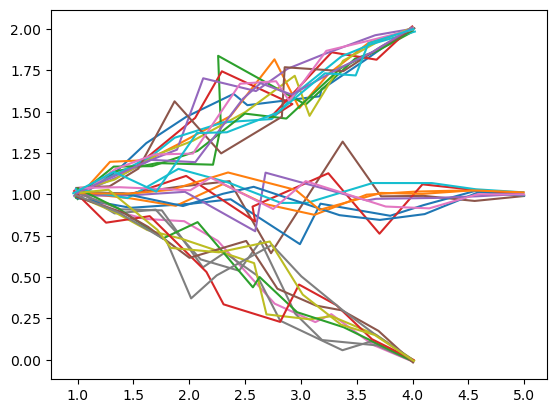

In [4]:
from marginal_datasets import sample_marginal_gaussian_dataset, marginal_variance_schedule, build_ground_truth_covariances
# ==============================================================================
# Marginal-Only 2D Gaussian Dataset Generator
# ==============================================================================
# This dataset has:
#   - Independent Gaussian noise per timestep (no temporal correlation)
#   - All trajectories end near the same point x_T* with small variance
#   - Known ground-truth covariance S_t for each timestep
#   - Mid-peak variance schedule (low at start/end, high in middle)
# ==============================================================================
# Configuration
MARGINAL_CONFIG = {
    'n_samples': 25000,
    'T': 10,
    'x_start': np.array([1.0, 1.0]),
    'x_T_star': np.array([[5.0, 1.0], [4.0, 2.0], [4.0, 0]]), # End-points
    'sigma_min': 0.02,
    'sigma_max': 0.15,
    'schedule': 'cosine',  # 'cosine', 'gaussian', or 'quadratic'
    'isotropic': True,     # True for circular, False for elliptical
    'endpoint_sigma': 0.01,  # Small variance at endpoint (avoids whitening issues)
    'seed': 42
}

# ==============================================================================
# Marginal Dataset Adapter - compatible with existing training functions
# ==============================================================================

def sample_marginal2D_mixture(n):
    """
    Sample from marginal Gaussian dataset with same interface as sample_mixture().

    Args:
        n: Number of samples

    Returns:
        X_flat: [n, D] flattened trajectories (D = 2*T)
        None: Placeholder for compatibility
    """
    X, mu, S_true, meta = sample_marginal_gaussian_dataset(
        n_samples=n,
        T=MARGINAL_CONFIG['T'],
        x_start=MARGINAL_CONFIG['x_start'],
        x_T_star=MARGINAL_CONFIG['x_T_star'],
        sigma_min=MARGINAL_CONFIG['sigma_min'],
        sigma_max=MARGINAL_CONFIG['sigma_max'],
        schedule=MARGINAL_CONFIG['schedule'],
        isotropic=MARGINAL_CONFIG['isotropic'],
        endpoint_sigma=MARGINAL_CONFIG['endpoint_sigma']
    )

    # Flatten to [n, D] format to match sample_mixture interface
    X_flat = X.reshape(n, -1)
    return X_flat, None

sample_mixture = sample_marginal2D_mixture
print("Scenario: ", SCENARIO)
N_s = 30
Y_vis, lbl = sample_mixture(N_s)
for i in range(N_s):
    traj = Y_vis[i].reshape(T,2)
    plt.plot(traj[:,0], traj[:,1])

[MARGINAL DATASET] Generating dataset with config:
  n_samples: 25000
  T: 10
  x_start: [1. 1.]
  x_T_star: [[5. 1.]
 [4. 2.]
 [4. 0.]]
  sigma_min: 0.02
  sigma_max: 0.15
  schedule: cosine
  isotropic: True
  endpoint_sigma: 0.01
  seed: 42

[MARGINAL DATASET] Generated:
  X shape: (25000, 10, 2)
  mu shape: (3, 10, 2)
  S_true shape: (10, 2, 2)

[EMPIRICAL vs GROUND TRUTH] (should match for large n_samples)
  t=0: Relative Frobenius error = 0.0183
  t=5: Relative Frobenius error = 7.2379
  t=8: Relative Frobenius error = 317.7376

VISUALIZATIONS


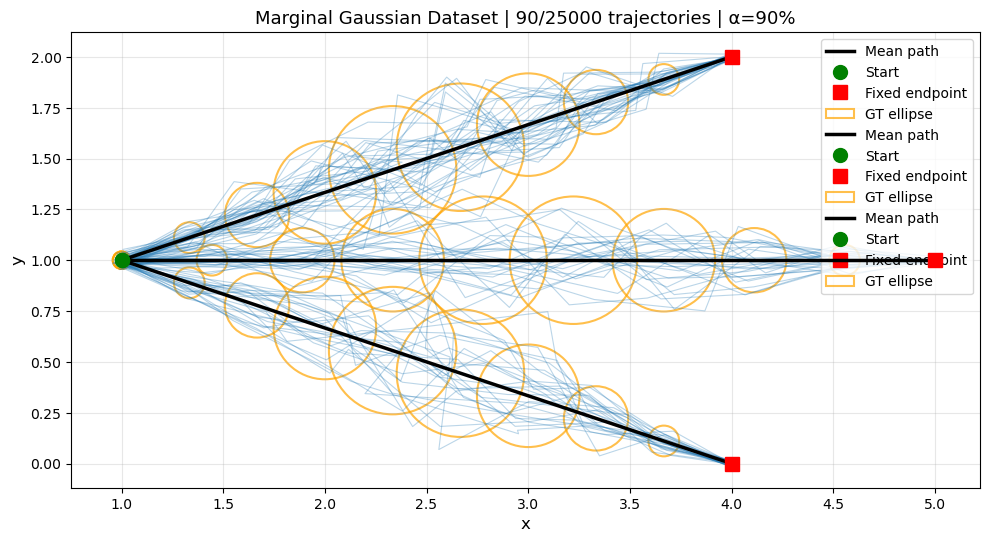

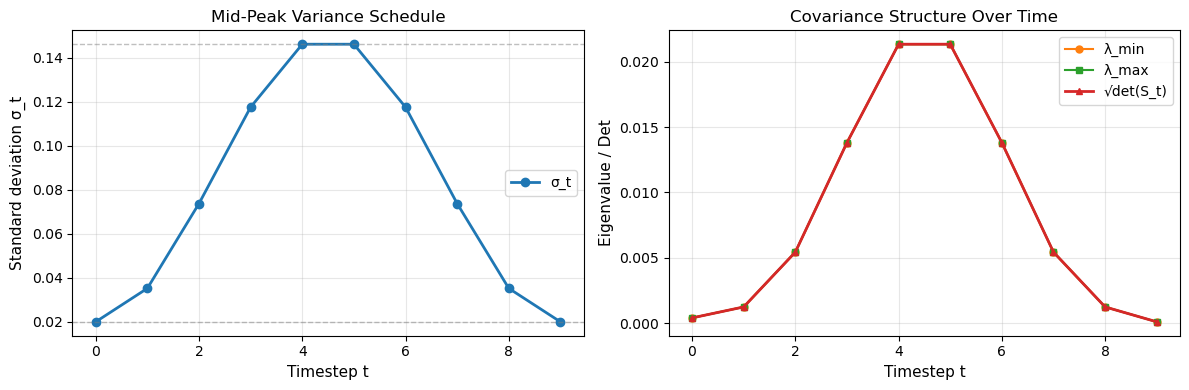

In [5]:
# ==============================================================================
# Generate and Visualize Marginal Gaussian Dataset
# ==============================================================================
from marginal_datasets import (
    plot_dataset_overview,
    plot_variance_schedule,
    plot_sample_histograms
)

print("[MARGINAL DATASET] Generating dataset with config:")
for k, v in MARGINAL_CONFIG.items():
    print(f"  {k}: {v}")

# Generate dataset
X_marginal, mu_marginal, S_true_marginal, meta_marginal = sample_marginal_gaussian_dataset(**MARGINAL_CONFIG)

print(f"\n[MARGINAL DATASET] Generated:")
print(f"  X shape: {X_marginal.shape}")
print(f"  mu shape: {mu_marginal.shape}")
print(f"  S_true shape: {S_true_marginal.shape}")

sigma_sched = marginal_variance_schedule(MARGINAL_CONFIG['T'], MARGINAL_CONFIG['sigma_min'], MARGINAL_CONFIG['sigma_max'], MARGINAL_CONFIG['schedule'])
peak_idx = np.argmax(sigma_sched)

# Compute empirical covariance and compare with ground truth (for first few timesteps)
print(f"\n[EMPIRICAL vs GROUND TRUTH] (should match for large n_samples)")
for t in [0, MARGINAL_CONFIG['T']//2, MARGINAL_CONFIG['T']-2]:
    S_empirical = np.cov(X_marginal[:, t, :].T)
    S_gt = S_true_marginal[t]
    frob_error = np.linalg.norm(S_empirical - S_gt, 'fro') / (np.linalg.norm(S_gt, 'fro') + 1e-12)
    print(f"  t={t}: Relative Frobenius error = {frob_error:.4f}")

print("\n" + "="*80)
print("VISUALIZATIONS")
print("="*80)
plot_dataset_overview(X_marginal, mu_marginal, S_true_marginal, alpha=0.9, n_show=90, ellipse_stride=1)

# Visualization 2: Variance schedule
plot_variance_schedule(sigma_sched, S_true_marginal)

# # Visualization 3: Sample histograms at key timesteps
# plot_sample_histograms(X_marginal, mu_marginal, S_true_marginal, 
#                        timesteps=[0, MARGINAL_CONFIG['T']//4, MARGINAL_CONFIG['T']//2, 
#                                  3*MARGINAL_CONFIG['T']//4, MARGINAL_CONFIG['T']-1], 
#                        alpha=0.9)

[DATASET] Generating fixed train/test split...
[DATASET] Train: (25000, 20), Test: (5000, 20)
[DATASET] Train seed: 1, Test seed: 1001


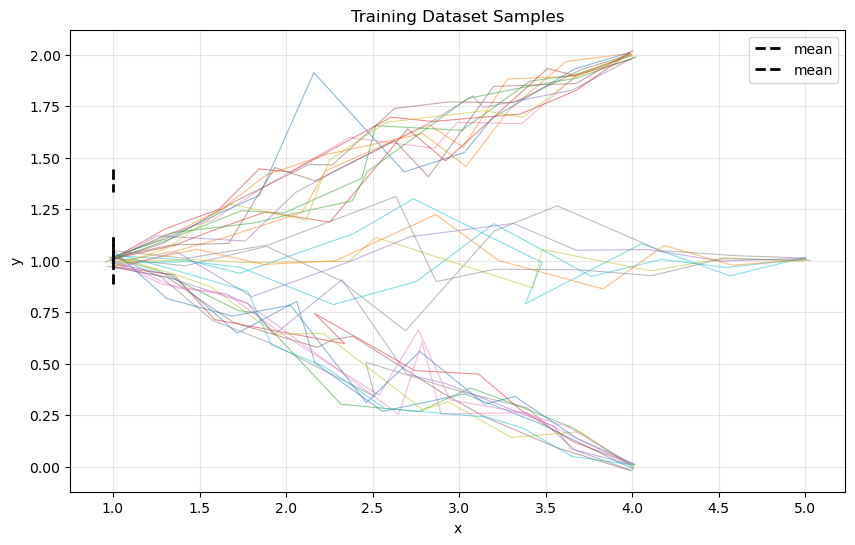

In [6]:
# ==============================================================================
# Fixed Train/Test Split (IMPORTANT: Do this before training!)
# ==============================================================================
print("[DATASET] Generating fixed train/test split...")

# Training data (seed=SEED for reproducibility)
TRAIN_SIZE = 25000
X_train, mu_train, S_true_train, meta_train = sample_marginal_gaussian_dataset(
    n_samples=TRAIN_SIZE,
    T=MARGINAL_CONFIG['T'],
    x_start=MARGINAL_CONFIG['x_start'],
    x_T_star=MARGINAL_CONFIG['x_T_star'],
    sigma_min=MARGINAL_CONFIG['sigma_min'],
    sigma_max=MARGINAL_CONFIG['sigma_max'],
    schedule=MARGINAL_CONFIG['schedule'],
    isotropic=MARGINAL_CONFIG['isotropic'],
    endpoint_sigma=MARGINAL_CONFIG['endpoint_sigma'],
    seed=SEED  # Use main SEED for training
)

# Test data (different seed to avoid leakage)
TEST_SIZE = 5000
X_test, mu_test, S_true_test, meta_test = sample_marginal_gaussian_dataset(
    n_samples=TEST_SIZE,
    T=MARGINAL_CONFIG['T'],
    x_start=MARGINAL_CONFIG['x_start'],
    x_T_star=MARGINAL_CONFIG['x_T_star'],
    sigma_min=MARGINAL_CONFIG['sigma_min'],
    sigma_max=MARGINAL_CONFIG['sigma_max'],
    schedule=MARGINAL_CONFIG['schedule'],
    isotropic=MARGINAL_CONFIG['isotropic'],
    endpoint_sigma=MARGINAL_CONFIG['endpoint_sigma'],
    seed=SEED + 1000  # Different seed for test set
)

# Flatten for compatibility with existing code
X_train_flat = X_train.reshape(TRAIN_SIZE, -1)  # [TRAIN_SIZE, D]
X_test_flat = X_test.reshape(TEST_SIZE, -1)     # [TEST_SIZE, D]

print(f"[DATASET] Train: {X_train_flat.shape}, Test: {X_test_flat.shape}")
print(f"[DATASET] Train seed: {SEED}, Test seed: {SEED+1000}")

# Visualize a few samples from train set
plt.figure(figsize=(10, 6))
for i in range(30):
    traj = X_train[i]
    plt.plot(traj[:,0], traj[:,1], alpha=0.5, lw=0.8)
plt.plot(mu_train[:,0], mu_train[:,1], 'k--', lw=2, label='mean')
plt.title('Training Dataset Samples')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[CONFIG] SCENARIO=mid_peak, NUM_TUBES=50, WHITEN=False
[DSM] Training ScoreNet on 25000 train samples...
[DSM  250] loss=7.7127e-01
[DSM  500] loss=6.8071e-01
[DSM  750] loss=6.7561e-01
[DSM 1000] loss=6.5600e-01
[DSM 1250] loss=6.7593e-01
[DSM 1500] loss=6.4449e-01
[DSM 1750] loss=6.2367e-01
[DSM 2000] loss=6.6591e-01
[DSM 2250] loss=6.2948e-01
[DSM 2500] loss=6.4066e-01
[DSM 2750] loss=6.5189e-01
[DSM 3000] loss=6.2496e-01
[DSM 3250] loss=5.9696e-01
[DSM 3500] loss=6.1237e-01
[DSM 3750] loss=6.0406e-01
[DSM 4000] loss=6.0477e-01
[DSM 4250] loss=6.0091e-01
[DSM 4500] loss=5.9782e-01
[DSM 4750] loss=6.0653e-01
[DSM 5000] loss=6.1146e-01
[DSM 5250] loss=5.8661e-01
[DSM 5500] loss=6.0350e-01
[DSM 5750] loss=5.7808e-01
[DSM 6000] loss=5.7454e-01
[DSM 6250] loss=5.7685e-01
[DSM 6500] loss=5.8991e-01
[DSM 6750] loss=5.5526e-01
[DSM 7000] loss=5.7803e-01
[DSM 7250] loss=5.6920e-01
[DSM 7500] loss=5.9779e-01
[DSM 7750] loss=5.5473e-01
[DSM 8000] loss=5.5575e-01
[DSM 8250] loss=6.1838e-01
[DSM

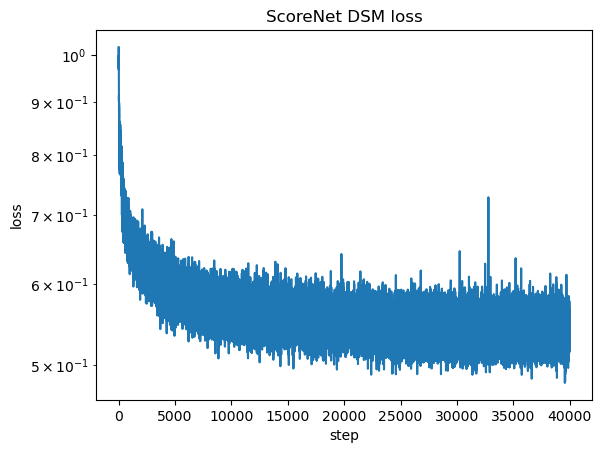

[PH] Training PrecisionHead on 25000 train samples...
[PH  100] L_prec=6.6500e+03  (reg≈2.67e+02)
[PH  200] L_prec=1.9126e+04  (reg≈2.84e+02)
[PH  300] L_prec=5.8088e+03  (reg≈2.45e+02)
[PH  400] L_prec=5.4817e+03  (reg≈2.41e+02)
[PH  500] L_prec=9.9801e+03  (reg≈2.57e+02)
[PH  600] L_prec=6.5070e+03  (reg≈2.20e+02)
[PH  700] L_prec=5.7790e+03  (reg≈2.11e+02)
[PH  800] L_prec=8.2763e+03  (reg≈2.22e+02)
[PH  900] L_prec=4.4320e+03  (reg≈1.92e+02)
[PH 1000] L_prec=5.8616e+03  (reg≈1.77e+02)
[PH 1100] L_prec=7.5842e+03  (reg≈1.82e+02)
[PH 1200] L_prec=4.6694e+03  (reg≈1.56e+02)
[PH 1300] L_prec=5.1804e+03  (reg≈1.42e+02)
[PH 1400] L_prec=5.7342e+03  (reg≈1.45e+02)
[PH 1500] L_prec=4.2940e+03  (reg≈1.26e+02)
[PH 1600] L_prec=4.5339e+03  (reg≈1.18e+02)
[PH 1700] L_prec=6.2571e+03  (reg≈1.18e+02)
[PH 1800] L_prec=4.3230e+03  (reg≈1.06e+02)
[PH 1900] L_prec=4.4140e+03  (reg≈9.98e+01)
[PH 2000] L_prec=6.0415e+03  (reg≈1.03e+02)


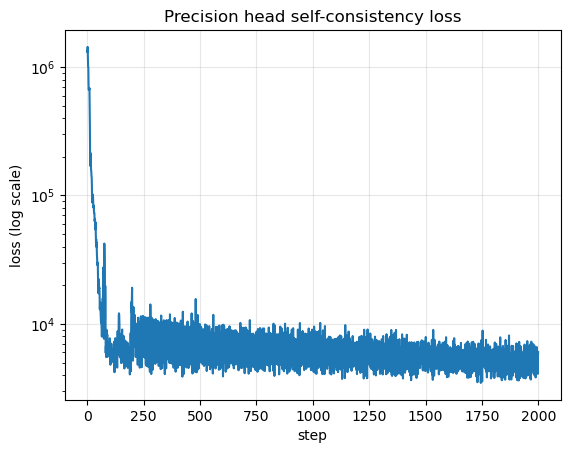


[TRAINING COMPLETE] Score net and precision head trained on 25000 samples


In [7]:
# ------------------------------
# Train the score model and the prediction head using FIXED train data
# ------------------------------
print(f"[CONFIG] SCENARIO={SCENARIO}, NUM_TUBES={NUM_TUBES}, WHITEN={WHITEN}")

# Whitening on train data
if WHITEN:
    print("[WHITEN] Computing whitening from training data...")
    std = X_train_flat.std(axis=0) + 1e-6
    W_VEC = 1.0 / std
    W_VEC = np.clip(W_VEC, None, 100.0)
    print("[WHITEN] median std:", float(np.median(std)), "min:", float(std.min()), "max:", float(std.max()))
    print("W_VEC shape:", W_VEC.shape)
    print("W_VEC min:", W_VEC.min(), "max:", W_VEC.max())
    print("Last 4 dimensions (endpoint):", W_VEC[-4:])
    print("Ratio max/min:", W_VEC.max()/W_VEC.min())

def whiten(X): return X * W_VEC

# Train ScoreNet (teacher) on train data
teacher = None
if USE_SCORENET_TEACHER:
    print(f"[DSM] Training ScoreNet on {X_train_flat.shape[0]} train samples...")
    model = ScoreNet(D).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DSM_LR)
    
    # Use train data (whitened if needed)
    Xpool = whiten(X_train_flat) if WHITEN else X_train_flat
    Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)
    
    def sample_sigma(batch):
        u = torch.rand(batch, device=DEVICE)
        log_min, log_max = math.log(SIGMA_MIN), math.log(SIGMA_MAX)
        return torch.exp(log_min + u*(log_max - log_min))
    
    dsm_hist = []
    for step in range(1, DSM_STEPS+1):
        idx = np.random.choice(Xpool_t.shape[0], size=min(DSM_BATCH, Xpool_t.shape[0]), replace=False)
        x0 = Xpool_t[idx]; sigma = sample_sigma(x0.shape[0])
        z = torch.randn_like(x0); x = x0 + sigma.view(-1,1)*z
        target = - z / sigma.view(-1,1)
        s_pred = model(x, sigma)
        w = (sigma**2).view(-1,1)
        loss = torch.mean(w * (s_pred - target)**2)
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if step % 250 == 0 or step == DSM_STEPS:
            print(f"[DSM {step:4d}] loss={float(loss.item()):.4e}")
        dsm_hist.append(float(loss.item()))
    
    score_net = model
    plt.figure()
    plt.plot(dsm_hist)
    plt.yscale('log')
    plt.title("ScoreNet DSM loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.show()
    teacher = score_net

elif USE_EPSNET_TEACHER:
    print(f"[DSM] Training EpsNet on {X_train_flat.shape[0]} train samples...")
    model = EpsNet(D).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DSM_LR)

    Xpool = whiten(X_train_flat) if WHITEN else X_train_flat
    Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)

    def sample_sigma(batch):
        u = torch.rand(batch, device=DEVICE)
        log_min, log_max = math.log(SIGMA_MIN), math.log(SIGMA_MAX)
        return torch.exp(log_min + u*(log_max - log_min))

    dsm_hist = []
    for step in range(1, DSM_STEPS+1):
        idx = np.random.choice(Xpool_t.shape[0], size=DSM_BATCH, replace=False)
        x0 = Xpool_t[idx]
        sigma = sample_sigma(x0.size(0))   # (batch,)
        eps = torch.randn_like(x0)         # ground truth ε
        x = x0 + sigma.view(-1,1) * eps    # noisy sample
        eps_hat = model(x, sigma)
        loss = ((eps_hat - eps)**2).mean()
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if step % 1000 == 0 or step == DSM_STEPS:
            print(f"[EPS {step:4d}] loss={loss.item():.4e}")
        dsm_hist.append(loss.item())

    eps_net = model
    plt.figure()
    plt.plot(dsm_hist)
    plt.yscale('log')
    plt.title("EpsNet DSM loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.show()
    teacher = eps_net

# Train Precision Head on train data
print(f"[PH] Training PrecisionHead on {X_train_flat.shape[0]} train samples...")
head = PrecisionHead(D, T, hidden=220, use_low_rank=USE_LOW_RANK_TAIL, rank_r=RANK_R).to(DEVICE)
opt = torch.optim.Adam(head.parameters(), lr=PH_LR)

# Use train data (whitened if needed)
Xpool = whiten(X_train_flat) if WHITEN else X_train_flat
Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)

ph_hist = []
for step in range(1, PH_STEPS+1):
    idx = np.random.choice(Xpool_t.shape[0], size=min(PH_BATCH, Xpool_t.shape[0]), replace=False)
    yb = Xpool_t[idx]
    L_list, R_list = head(yb)
    loss_prec = 0.0; loss_reg = 0.0
    
    for _ in range(PH_PROBES):
        u = torch.randn_like(yb)
        if teacher is None:
            raise NotImplementedError("Use ScoreNet teacher under whitening.")
        h = None
        if USE_SCORENET_TEACHER:
            h = hvp_from_scorenet(teacher, yb, SIGMA_EVALS, u)
        elif USE_EPSNET_TEACHER:
            h = hvp_from_epsnet(teacher, yb, SIGMA_EVALS, u)
        Lu_total = []
        for b in range(yb.shape[0]):
            Lb = L_list[b]; tmp = Lb.t().matmul(u[b]); Au = Lb.matmul(tmp)
            if USE_LOW_RANK_TAIL and (R_list[b] is not None):
                Rb = R_list[b]; Au = Au + Rb.matmul(Rb.t().matmul(u[b]))
            Lu_total.append(Au)
        Lu_total = torch.stack(Lu_total, dim=0)
        loss_prec = loss_prec + F.mse_loss(Lu_total + h, torch.zeros_like(h))
    
    loss_prec = loss_prec / PH_PROBES
    if USE_LOW_RANK_TAIL:
        for b in range(yb.shape[0]):
            Rb = R_list[b]
            if Rb is not None:
                loss_reg = loss_reg + LAMBDA_R_L2 * (Rb**2).sum() + LAMBDA_R_SMOOTH * temporal_smoothness_penalty(Rb)
    
    loss = loss_prec + loss_reg
    opt.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0)
    opt.step()
    ph_hist.append(float(loss_prec.item()))
    
    if step % 100 == 0 or step == PH_STEPS:
        print(f"[PH {step:4d}] L_prec={ph_hist[-1]:.4e}  (reg≈{float(loss_reg.item()) if torch.is_tensor(loss_reg) else loss_reg:.2e})")

plt.figure()
plt.plot(ph_hist)
plt.yscale('log')
plt.title("Precision head self-consistency loss")
plt.xlabel("step")
plt.ylabel("loss (log scale)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n[TRAINING COMPLETE] Score net and precision head trained on {X_train_flat.shape[0]} samples")

W_VEC: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


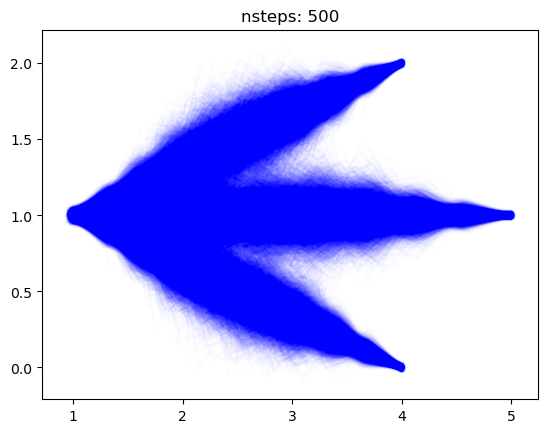

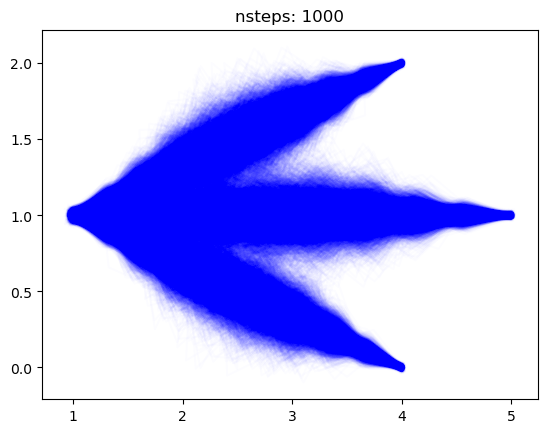

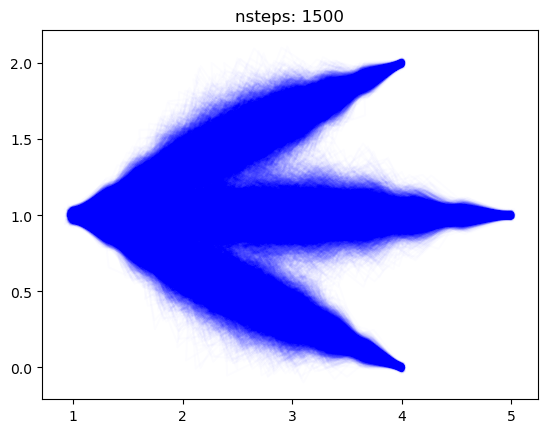

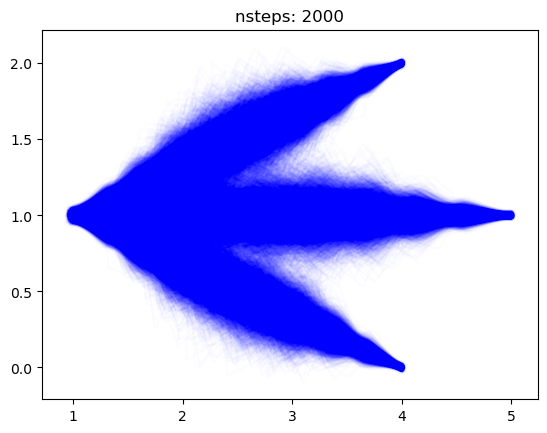

In [8]:
# 3. Sample new trajectories
n_samples = 100
X_temp = whiten(X_train) if WHITEN else X_train
print("W_VEC:", W_VEC)

for n_steps in range(500, 2001, 500):
    # samples, _ = sample_from_scorenet(teacher, n_samples=n_samples, n_steps=n_steps)
    samples, _ = sample_from_epsnet(teacher, n_samples=n_samples, n_steps=n_steps)
    samples = samples.reshape(n_samples, T, 2)  # reshape to (num_samples, T, 2)

    for i in range(X_temp.shape[0]):
        traj = X_temp[i].reshape(T,2)
        plt.plot(traj[:,0], traj[:,1], alpha=0.01, color='blue')

    for traj in samples:
        plt.plot(traj[:,0], traj[:,1], alpha=0.6, color='red')
        
    plt.title(f"nsteps: {n_steps}")
    plt.show()

In [9]:
# -------- Calibration set (precompute m2) --------
CAL_SCENES = 300      # reduce if needed for faster turnaround but poorer calibration. 
start = time.time()
Yp_cal, Yt_cal, m2_cal = precompute_union_m2(head, n_scenes=CAL_SCENES, num_tubes=NUM_TUBES, diversify=True,
                                             diversify_mode="waypoints", batch=2048)
print(f"[TIME] precompute (cal) {time.time()-start:.2f}s")

# Per-horizon UNION calibration via closed-form quantiles
if per_horizon_calibration:
    print("[CALIBRATION] Performing per-horizon UNION calibration via closed-form quantiles...")
    s_table = calibrate_union_per_horizon_quantile(m2_cal, alphas=ALPHAS_GRID)
else:
    s_table = np.ones((T, len(ALPHAS_GRID)), dtype=np.float64)
# PATH γ(α) via closed-form quantiles
if per_path_calibration:
    print("[CALIBRATION] Performing PATH γ(α) calibration via closed-form quantiles...")
    gamma_vec = calibrate_union_path_gamma_quantile(m2_cal, s_table, alphas=ALPHAS_GRID)
else:
    gamma_vec = np.ones((len(ALPHAS_GRID),), dtype=np.float64)
    
print("[CALIBRATION] s_table shape:", s_table.shape,"s:", s_table," gamma_vec:", gamma_vec)


[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 299.30s
[TIME] precompute (cal) 299.32s
[CALIBRATION] Performing per-horizon UNION calibration via closed-form quantiles...
[CALIBRATION] Performing PATH γ(α) calibration via closed-form quantiles...
[CALIBRATION] s_table shape: (10, 5) s: [[0.18930238 0.20963079 0.2391189  0.26807247 0.30696443]
 [0.35814349 0.36753938 0.36168    0.3993549  0.41950106]
 [0.37488804 0.38931512 0.40115451 0.42668111 0.44382732]
 [0.46987904 0.43984776 0.4499023  0.4346978  0.45729224]
 [0.37173554 0.37597151 0.38202515 0.44477426 0.49796382]
 [0.36309836 0.39023951 0.40617051 0.42673484 0.4499385 ]
 [0.5194616  0.47402252 0.47387021 0.46182164 0.4493866 ]
 [0.37518167 0.38865961 0.38780214 0.44351134 0.47515597]
 [0.37335379 0.39697131 0.42491383 0.45472469 0.47971789]
 [0.19963062 0.20341858 0.21040652 0.25066497 0.27499996]]  gamma_vec: [5.71717622 4.5792906  3.99431269 3.25959942 2.79922992]


In [21]:
print((s_table * gamma_vec) ** 2)

[[1.17131928 0.92152377 0.91224593 0.76354194 0.73833466]
 [4.19254073 2.83272332 2.08705121 1.69451919 1.37893332]
 [4.5937391  3.17832968 2.56748236 1.93435109 1.5434949 ]
 [7.21664435 4.0569643  3.22939039 2.00772093 1.6385693 ]
 [4.51680485 2.96419161 2.32845601 2.10187922 1.94299963]
 [4.30934963 3.19344084 2.63209096 1.93483822 1.58629314]
 [8.82002994 4.71188143 3.58263798 2.26608931 1.58240405]
 [4.60093812 3.16763575 2.39941031 2.08995974 1.76908834]
 [4.55621585 3.30456775 2.88061924 2.19697713 1.80322108]
 [1.30261925 0.86771611 0.70632166 0.66759912 0.59257373]]


[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 302.19s


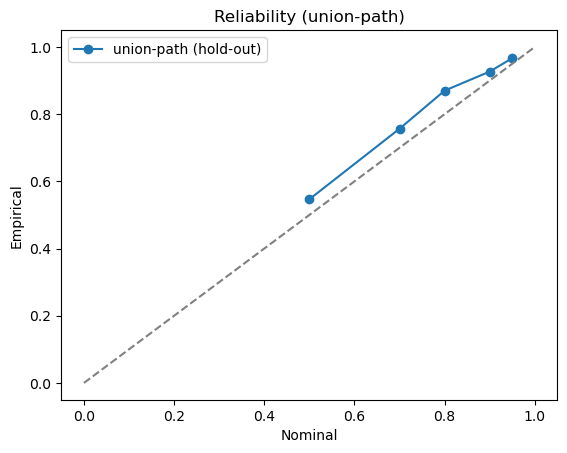

Nominal 50% -> Empirical 54.67%
Nominal 70% -> Empirical 75.67%
Nominal 80% -> Empirical 87.00%
Nominal 90% -> Empirical 92.67%
Nominal 95% -> Empirical 96.67%


In [10]:
# -------- Hold-out evaluation (recommended) --------
EVAL_SCENES = 300
Yp_eval, Yt_eval, m2_eval = precompute_union_m2(head, n_scenes=EVAL_SCENES, num_tubes=NUM_TUBES, diversify=True,
                                                diversify_mode="waypoints", batch=2048)

alphas_test = [0.50, 0.70, 0.80, 0.90, 0.95]
cov_emp = []
for a in alphas_test:
    cov = evaluate_union_path_from_m2(m2_eval, s_table, gamma_vec, alpha=a)
    cov_emp.append(cov)
plt.figure()
plt.plot(alphas_test, cov_emp, marker='o', label='union-path (hold-out)')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("Nominal"); plt.ylabel("Empirical"); plt.title("Reliability (union-path)"); plt.legend(); plt.show()
for a,c in zip(alphas_test, cov_emp):
    print(f"Nominal {int(100*a)}% -> Empirical {100*c:.2f}%")

(50, 20)
(50, 20)


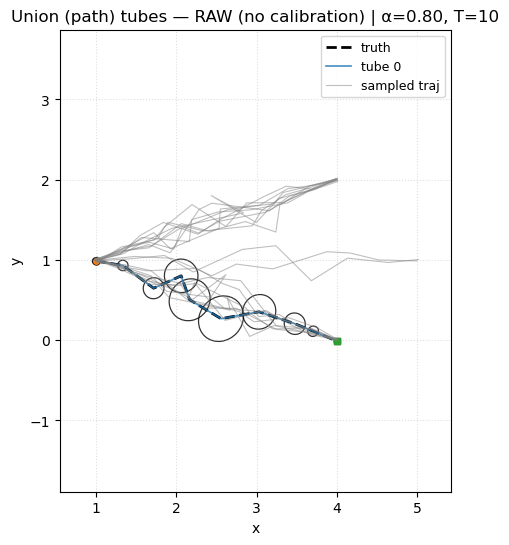

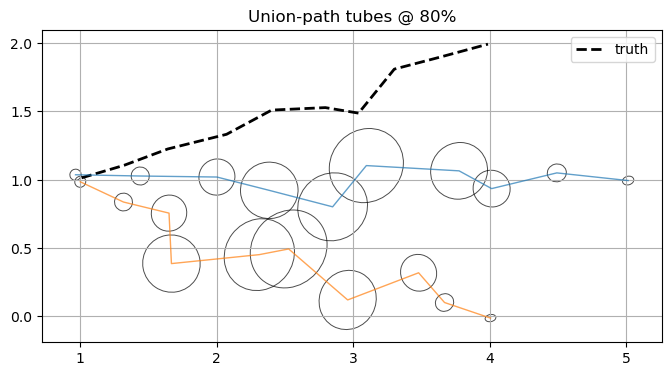

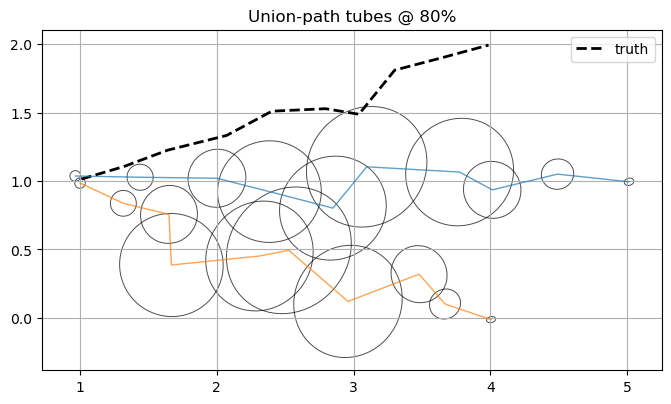

In [11]:
# -------- Visualization on a few scenes --------
alp = 0.80
# Pick a random eval scene and visualize up to 8 tubes
# this will oook like a big mess. :P 
idx = np.random.randint(EVAL_SCENES)
s_vec = s_table[:, int(np.argmin(np.abs(ALPHAS_GRID - alp)))]
gamma = float(gamma_vec[int(np.argmin(np.abs(ALPHAS_GRID - alp)))])

print(Yp_eval[idx].shape)
print(X_train_flat[:50,:].shape)
# plot_scene_union_tubes_raw(head, Yp_eval[idx], Yt_eval[idx], alpha=alp,max_tubes_show=1, num_real_traj=80)
# # Use X_train_flat
s_raw = np.ones((T, len(ALPHAS_GRID)), dtype=np.float64)[:, int(np.argmin(np.abs(ALPHAS_GRID - alp)))]
gamma_raw = float(np.ones((len(ALPHAS_GRID),), dtype=np.float64)[int(np.argmin(np.abs(ALPHAS_GRID - alp)))])
plot_scene_union_tubes_raw(head, X_train_flat[:50,:], X_train_flat[0], alpha=alp,max_tubes_show=1, num_real_traj=20)

plot_scene_union_tubes(head, Yp_eval[idx], Yt_eval[idx], alpha=alp, s_vec=s_raw, gamma=gamma_raw,
                       max_tubes_show=min(2, NUM_TUBES),
                       title=f"Union-path tubes @ {int(100*alp)}%")

plot_scene_union_tubes(head, Yp_eval[idx], Yt_eval[idx], alpha=alp, s_vec=s_vec, gamma=gamma,
                       max_tubes_show=min(2, NUM_TUBES),
                       title=f"Union-path tubes @ {int(100*alp)}%")


## Evaluation (coverage and NLL)

In [12]:
from typing import Optional
from evaluation_utils import (
    compute_nll_single_tube,
    compute_sharpness_metrics,
)

def evaluate_distribution_level(
    head: torch.nn.Module,
    X_train: np.ndarray,
    X_test: np.ndarray,
    T: int,
    N_SCENES: int = 50,
    alpha: float = 0.50,
    whiten: bool = False,
    W_VEC: Optional[np.ndarray] = None,
    precision_ridge: float = 1e-7,
    woodbury_jitter: float = 1e-5,
    eigen_floor: float = 1e-9,
    batch_size: int = 256,
    verbose: bool = True,
    s_vec: Optional[np.ndarray] = None,
    gamma: Optional[float] = None,
    S_true: Optional[np.ndarray] = None
) -> dict:
    
    if verbose:
        calib_str = ""
        if s_vec is not None and gamma is not None:
            calib_str = " (with calibration)"
        print(f"[EVAL] Generating {N_SCENES} unconditional tubes{calib_str}...")

    # Generate tubes (with optional calibration)
    Yp_eval, Yt_eval, m2_eval = precompute_union_m2(head, n_scenes=N_SCENES, num_tubes=NUM_TUBES, diversify=True,
                                                diversify_mode="waypoints", batch=2048)

    if verbose:
        print(f"[EVAL] Computing coverage and NLL for {N_SCENES} tubes on {X_test.shape[0]} test trajectories...")


    tau = chi2_ppf_df2(alpha)

    # 2.1 Empirical Coverage 
    nll_per_tube = np.zeros(N_SCENES, dtype=np.float64)
    rs_per_tube = np.zeros(N_SCENES, dtype=np.float64) if S_true is not None else None

    # Interpolate s_vec if needed
    # Here alphas are fixed grid; use nearest in grid
    denom = np.maximum((gamma**2) * (s_vec**2), 1e-16)
    max_over_t = (m2_eval / denom[np.newaxis, np.newaxis, :]).max(axis=2)    # [N,M]
    min_over_k = max_over_t.min(axis=1)                                  # [N]
    cov = float(np.mean(min_over_k <= tau))

    tubes = []
    for i in range(N_SCENES):
        Yp_scene = Yp_eval[i]            # (M, D)
        Yt_scene = Yt_eval[i]            # (D,)
        k_best, Lb, Rb, norm_m2_t = _select_union_path_tube(head, Yp_scene, Yt_scene, alpha, s_vec, gamma)
        mu = Yp_scene[k_best].reshape(T,2)
        truth = Yt_scene.reshape(T,2)

        S_blocks = np.zeros((T, 2, 2), dtype=np.float64)
        for t in range(T):
            # Get whitened covariance block
            S_w = block_marginal_from_factors(
                Lb, Rb, t,
                eps_M=woodbury_jitter,
                eigen_floor=eigen_floor,
                precision_ridge=precision_ridge
            ).cpu().numpy()

            # Unwhiten if needed
            if whiten:
                S_t = unwhiten_block(S_w, t, W_VEC)
            else:
                S_t = S_w

            # Apply calibration if provided
            if s_vec is not None and gamma is not None:
                # S_calibrated = (gamma * s_t)^2 * S_raw
                scale_factor = (gamma * s_vec[t]) ** 2
                S_blocks[t] = scale_factor * S_t
            else:
                S_blocks[t] = S_t

        tubes.append((mu, S_blocks))


    # 2.2 Sharpness 
    for i in range(N_SCENES):
        nll_per_tube[i] = compute_nll_single_tube(tubes[i], X_test, T)

        # Compute sharpness metrics if ground truth provided
        if S_true is not None:
            sharpness_metrics = compute_sharpness_metrics(tubes[i], S_true, T)
            rs_per_tube[i] = sharpness_metrics['rs_mean']

        if verbose and (i + 1) % 10 == 0:
            print(f"  Processed {i+1}/{N_SCENES} tubes")





    # Aggregate reliability metrics
    cov_mean = cov
    nll_mean = float(np.mean(nll_per_tube))
    nll_min = float(np.min(nll_per_tube))

    # Aggregate sharpness metrics if available
    results = {
        'cov_mean': cov_mean,
        'nll_mean': nll_mean,
        'nll_min': nll_min,
        'nll_per_tube': nll_per_tube,
        'tubes': tubes,
        'alpha': alpha
    }

    if S_true is not None:
        rs_mean = float(np.mean(rs_per_tube))
        # Compute PTV-ratio across all tubes
        ptv_ratios = []
        for i in range(N_SCENES):
            sharpness_metrics = compute_sharpness_metrics(tubes[i], S_true, T)
            ptv_ratios.append(sharpness_metrics['ptv_ratio'])
        ptv_ratio_mean = float(np.mean(ptv_ratios))

        results['rs_mean'] = rs_mean
        results['ptv_ratio'] = ptv_ratio_mean
        results['rs_per_tube'] = rs_per_tube

    if verbose:
        print(f"\n[RESULTS] Distribution-Level Evaluation @ α={alpha:.0%}")
        print(f"  Coverage (mean): {100*cov_mean:.2f}%")
        print(f"  NLL (mean):      {nll_mean:.4f}")
        print(f"  NLL (min):       {nll_min:.4f}")
        if S_true is not None:
            print(f"  RS_mean:         {results['rs_mean']:.4f}")
            print(f"  PTV-ratio:       {results['ptv_ratio']:.4f}")

    return results

In [13]:
# ==============================================================================
# Distribution-Level Evaluation (per EVALUATION.tex)
# ==============================================================================
# This evaluates the RAW (uncalibrated) precision head tubes at the 
# distribution level using:
#   - Path-wise Coverage@95 (all-or-nothing per trajectory)
#   - Negative Log-Likelihood (factorized over timesteps)
#
# Metrics reported:
#   (Cov_mean, Cov_max, NLL_mean, NLL_min)
# ==============================================================================

from evaluation_utils import (
    plot_distribution_evaluation,
    plot_tube_with_test_samples
)

# Configuration
N_SCENES_EVAL = 300      # Number of unconditional tubes to generate
EVAL_ALPHA = 0.8      # Coverage level

'''
print("="*80)
print("DISTRIBUTION-LEVEL EVALUATION (Raw Tubes, No Calibration)")
print("="*80)
print(f"Generating {N_SCENES_EVAL} unconditional tubes from training data...")
print(f"Evaluating on {X_test_flat.shape[0]} test trajectories at α={EVAL_ALPHA:.0%}")
print()

# Run full evaluation
results = evaluate_distribution_level(
    head=head,
    X_train=X_train_flat,
    X_test=X_test_flat,
    T=T,
    N_SCENES=N_SCENES_EVAL,
    alpha=EVAL_ALPHA,
    whiten=WHITEN,
    W_VEC=W_VEC if WHITEN else None,
    precision_ridge=PRECISION_RIDGE,
    woodbury_jitter=WOODBURY_JITTER,
    eigen_floor=EIGEN_FLOOR,
    batch_size=256,
    verbose=True
)

# Visualize results
plot_distribution_evaluation(results)

# Print summary
print("\n" + "="*80)
print("SUMMARY (Distribution-Level Metrics)")
print("="*80)
print(f"Coverage@{int(100*EVAL_ALPHA)}% (mean):  {100*results['cov_mean']:.2f}%  (expected: {100*EVAL_ALPHA:.0f}%)")
print(f"Coverage@{int(100*EVAL_ALPHA)}% (max):   {100*results['cov_max']:.2f}%")
print(f"NLL (mean):            {results['nll_mean']:.4f}")
print(f"NLL (min):             {results['nll_min']:.4f}")
print("="*80)
print()

# Interpretation
cov_gap = results['cov_mean'] - EVAL_ALPHA
if abs(cov_gap) < 0.05:
    print("✓ Coverage is well-calibrated (within 5% of nominal level)")
elif cov_gap > 0:
    print(f"⚠ Coverage is OVER-conservative by {100*abs(cov_gap):.1f}% (tubes are too wide)")
else:
    print(f"✗ Coverage is UNDER-conservative by {100*abs(cov_gap):.1f}% (tubes are too narrow!)")
print()
'''

'\nprint("="*80)\nprint("DISTRIBUTION-LEVEL EVALUATION (Raw Tubes, No Calibration)")\nprint("="*80)\nprint(f"Generating {N_SCENES_EVAL} unconditional tubes from training data...")\nprint(f"Evaluating on {X_test_flat.shape[0]} test trajectories at α={EVAL_ALPHA:.0%}")\nprint()\n\n# Run full evaluation\nresults = evaluate_distribution_level(\n    head=head,\n    X_train=X_train_flat,\n    X_test=X_test_flat,\n    T=T,\n    N_SCENES=N_SCENES_EVAL,\n    alpha=EVAL_ALPHA,\n    whiten=WHITEN,\n    W_VEC=W_VEC if WHITEN else None,\n    precision_ridge=PRECISION_RIDGE,\n    woodbury_jitter=WOODBURY_JITTER,\n    eigen_floor=EIGEN_FLOOR,\n    batch_size=256,\n    verbose=True\n)\n\n# Visualize results\nplot_distribution_evaluation(results)\n\n# Print summary\nprint("\n" + "="*80)\nprint("SUMMARY (Distribution-Level Metrics)")\nprint("="*80)\nprint(f"Coverage@{int(100*EVAL_ALPHA)}% (mean):  {100*results[\'cov_mean\']:.2f}%  (expected: {100*EVAL_ALPHA:.0f}%)")\nprint(f"Coverage@{int(100*EVAL_ALPHA

In [14]:
# ==============================================================================
# Visualize Example Tubes with Test Trajectories
# ==============================================================================
# Pick a few tubes (best and worst coverage) and visualize with test samples

# Find best and worst tubes
'''
cov_per_tube = results['cov_per_tube']
best_idx = int(np.argmax(cov_per_tube))
worst_idx = int(np.argmin(cov_per_tube))
median_idx = int(np.argsort(cov_per_tube)[len(cov_per_tube)//2])

print(f"Best tube (idx={best_idx}): coverage = {100*cov_per_tube[best_idx]:.2f}%")
print(f"Median tube (idx={median_idx}): coverage = {100*cov_per_tube[median_idx]:.2f}%")
print(f"Worst tube (idx={worst_idx}): coverage = {100*cov_per_tube[worst_idx]:.2f}%")
print()

# Visualize best tube
print("Visualizing BEST tube:")
plot_tube_with_test_samples(
    tube=results['tubes'][best_idx],
    X_test=X_test_flat,
    T=T,
    alpha=EVAL_ALPHA,
    n_show=50,
    ellipse_stride=1,
    title=f"Best Tube (Coverage: {100*cov_per_tube[best_idx]:.2f}%)"
)

# Visualize worst tube
print("Visualizing WORST tube:")
plot_tube_with_test_samples(
    tube=results['tubes'][worst_idx],
    X_test=X_test_flat,
    T=T,
    alpha=EVAL_ALPHA,
    n_show=50,
    ellipse_stride=1,
    title=f"Worst Tube (Coverage: {100*cov_per_tube[worst_idx]:.2f}%)"
)

# Visualize median tube
print("Visualizing MEDIAN tube:")
plot_tube_with_test_samples(
    tube=results['tubes'][median_idx],
    X_test=X_test_flat,
    T=T,
    alpha=EVAL_ALPHA,
    n_show=50,
    ellipse_stride=1,
    title=f"Median Tube (Coverage: {100*cov_per_tube[median_idx]:.2f}%)"
)
'''

'\ncov_per_tube = results[\'cov_per_tube\']\nbest_idx = int(np.argmax(cov_per_tube))\nworst_idx = int(np.argmin(cov_per_tube))\nmedian_idx = int(np.argsort(cov_per_tube)[len(cov_per_tube)//2])\n\nprint(f"Best tube (idx={best_idx}): coverage = {100*cov_per_tube[best_idx]:.2f}%")\nprint(f"Median tube (idx={median_idx}): coverage = {100*cov_per_tube[median_idx]:.2f}%")\nprint(f"Worst tube (idx={worst_idx}): coverage = {100*cov_per_tube[worst_idx]:.2f}%")\nprint()\n\n# Visualize best tube\nprint("Visualizing BEST tube:")\nplot_tube_with_test_samples(\n    tube=results[\'tubes\'][best_idx],\n    X_test=X_test_flat,\n    T=T,\n    alpha=EVAL_ALPHA,\n    n_show=50,\n    ellipse_stride=1,\n    title=f"Best Tube (Coverage: {100*cov_per_tube[best_idx]:.2f}%)"\n)\n\n# Visualize worst tube\nprint("Visualizing WORST tube:")\nplot_tube_with_test_samples(\n    tube=results[\'tubes\'][worst_idx],\n    X_test=X_test_flat,\n    T=T,\n    alpha=EVAL_ALPHA,\n    n_show=50,\n    ellipse_stride=1,\n    titl

CALIBRATED EVALUATION WITH SHARPNESS METRICS

[CALIBRATION] Using α=95%
  s_vec (per-horizon scales): [0.30696443 0.41950106 0.44382732 0.45729224 0.49796382 0.4499385
 0.4493866  0.47515597 0.47971789 0.27499996]
  gamma (path multiplier): 2.7992

[EVAL] Generating 300 unconditional tubes (with calibration)...
[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 298.74s
[EVAL] Computing coverage and NLL for 300 tubes on 5000 test trajectories...
  Processed 10/300 tubes
  Processed 20/300 tubes
  Processed 30/300 tubes
  Processed 40/300 tubes
  Processed 50/300 tubes
  Processed 60/300 tubes
  Processed 70/300 tubes
  Processed 80/300 tubes
  Processed 90/300 tubes
  Processed 100/300 tubes
  Processed 110/300 tubes
  Processed 120/300 tubes
  Processed 130/300 tubes
  Processed 140/300 tubes
  Processed 150/300 tubes
  Processed 160/300 tubes
  Processed 170/300 tubes
  Processed 180/300 tubes
  Processed 190/300 tubes
  Processed 200/300 tubes
  Processed 210/300 tubes
  Pro

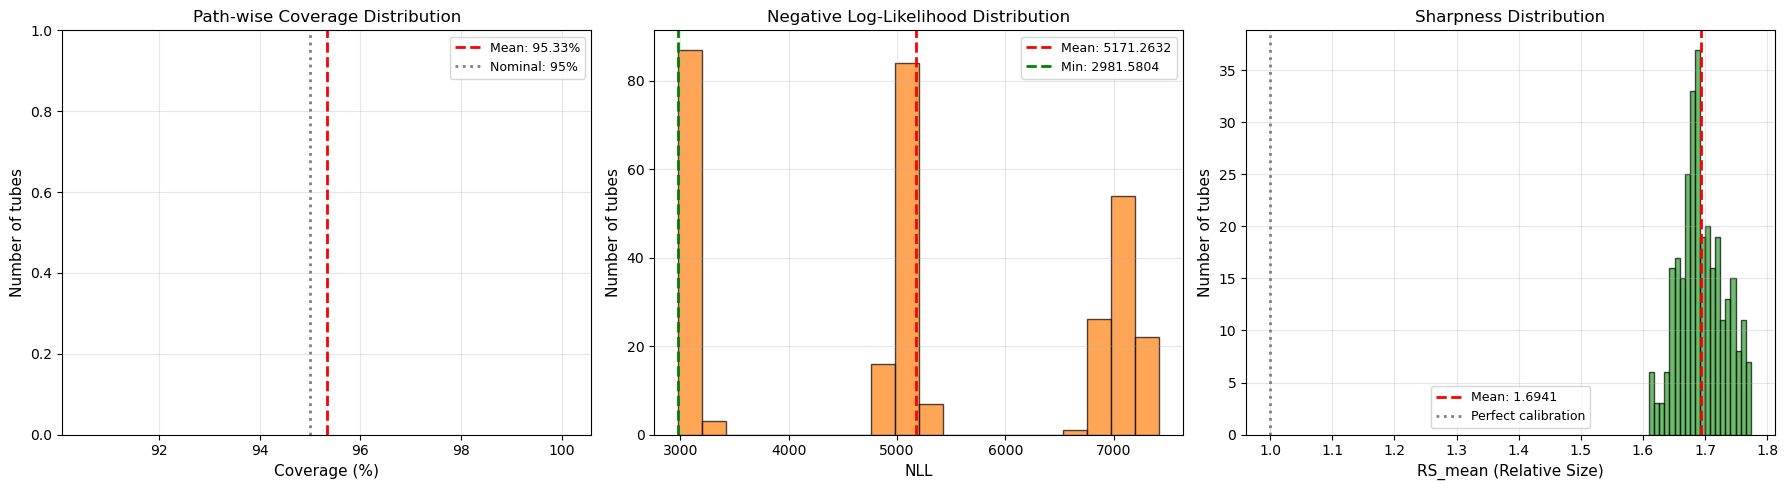

In [15]:
# ==============================================================================
# Calibrated Distribution-Level Evaluation with Ground Truth Comparison
# ==============================================================================

print("="*80)
print("CALIBRATED EVALUATION WITH SHARPNESS METRICS")
print("="*80)

# Select alpha for calibration (e.g., 0.95)
CALIB_ALPHA = 0.95
alpha_idx = int(np.argmin(np.abs(ALPHAS_GRID - CALIB_ALPHA)))
s_vec_calib = s_table[:, alpha_idx]
gamma_calib = gamma_vec[alpha_idx]

print(f"\n[CALIBRATION] Using α={CALIB_ALPHA:.0%}")
print(f"  s_vec (per-horizon scales): {s_vec_calib}")
print(f"  gamma (path multiplier): {gamma_calib:.4f}\n")

# Run calibrated evaluation with ground truth
results_calibrated = evaluate_distribution_level(
    head=head,
    X_train=X_train_flat,
    X_test=X_test_flat,
    T=T,
    N_SCENES=N_SCENES_EVAL,
    alpha=CALIB_ALPHA,
    s_vec=s_vec_calib,
    gamma=gamma_calib,
    S_true=S_true_test,  # Ground truth from marginal dataset
    whiten=WHITEN,
    W_VEC=W_VEC if WHITEN else None,
    precision_ridge=PRECISION_RIDGE,
    woodbury_jitter=WOODBURY_JITTER,
    eigen_floor=EIGEN_FLOOR,
    batch_size=256,
    verbose=True
)

# Print comprehensive summary
print("\n" + "="*80)
print("FINAL CALIBRATED METRICS")
print("="*80)
print(f"Coverage@{int(100*CALIB_ALPHA)}% (mean):  {100*results_calibrated['cov_mean']:.2f}%  (expected: {100*CALIB_ALPHA:.0f}%)")
print(f"NLL (mean):                {results_calibrated['nll_mean']:.4f}")
print(f"NLL (min):                 {results_calibrated['nll_min']:.4f}")
print(f"RS_mean (sharpness):       {results_calibrated['rs_mean']:.4f}  (1.0 = perfect)")
print(f"PTV-ratio (sharpness):     {results_calibrated['ptv_ratio']:.4f}  (1.0 = perfect)")
print("="*80)
print()

# Interpretation
cov_gap = results_calibrated['cov_mean'] - CALIB_ALPHA
if abs(cov_gap) < 0.05:
    print("✓ Coverage is well-calibrated (within 5% of nominal level)")
elif cov_gap > 0:
    print(f"⚠ Coverage is OVER-conservative by {100*abs(cov_gap):.1f}% (tubes are too wide)")
else:
    print(f"✗ Coverage is UNDER-conservative by {100*abs(cov_gap):.1f}% (tubes are too narrow!)")

rs_gap = results_calibrated['rs_mean'] - 1.0
if abs(rs_gap) < 0.2:
    print(f"✓ Sharpness is well-calibrated (RS_mean ≈ 1.0)")
elif rs_gap > 0:
    print(f"⚠ Tubes are OVER-DISPERSED by {100*rs_gap:.1f}% (RS_mean > 1.0)")
else:
    print(f"⚠ Tubes are UNDER-DISPERSED by {100*abs(rs_gap):.1f}% (RS_mean < 1.0)")
print()

# Visualize calibrated results
plot_distribution_evaluation(results_calibrated)


RISK-SIZE PARETO CURVE
Sweeping calibration levels to generate Pareto frontier...
Alpha levels: [0.5  0.7  0.8  0.9  0.95]

[RISK-SIZE CURVE] Evaluating 5 alpha levels...

[Alpha 1/5] α=0.50
[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 301.07s
  Coverage: 50.00%, RS_mean: 5.0357, PTV-ratio: 5.6690

[Alpha 2/5] α=0.70
[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 297.98s
  Coverage: 71.67%, RS_mean: 3.2761, PTV-ratio: 3.5640

[Alpha 3/5] α=0.80
[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 293.76s
  Coverage: 81.33%, RS_mean: 2.6329, PTV-ratio: 2.8312

[Alpha 4/5] α=0.90
[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 296.52s
  Coverage: 87.67%, RS_mean: 2.0304, PTV-ratio: 2.0784

[Alpha 5/5] α=0.95
[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 296.58s
  Coverage: 96.33%, RS_mean: 1.6919, PTV-ratio: 1.7178

[RISK-SIZE CURVE] Evaluation complete

PARETO FRONTIER VISUALIZATION


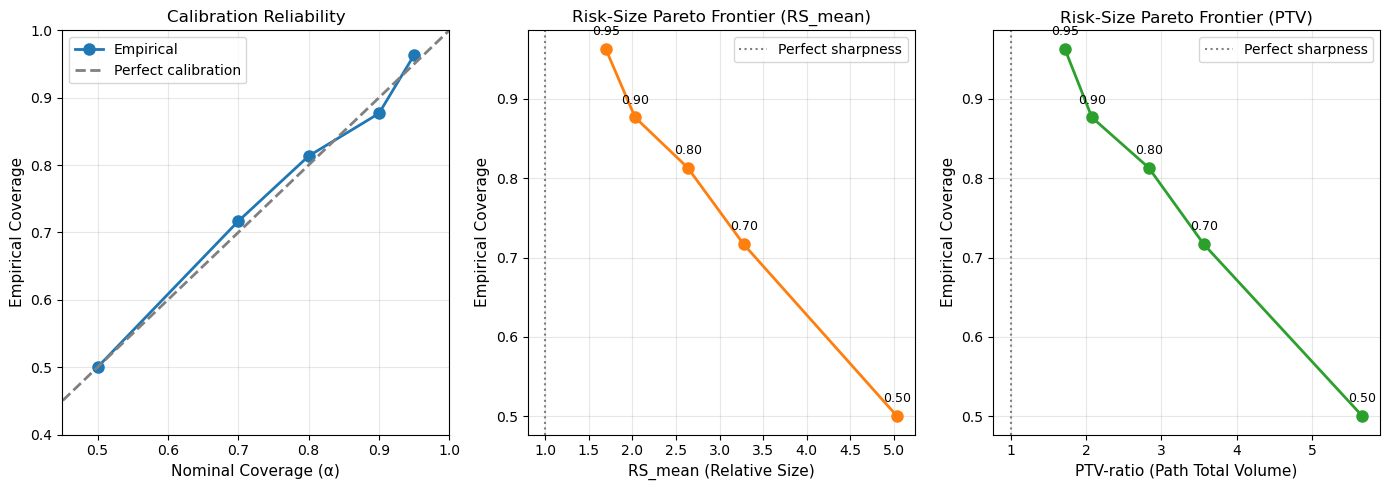


RISK-SIZE TABLE
Alpha    Nominal    Coverage     RS_mean      PTV-ratio    Mean Area   
--------------------------------------------------------------------------------
0.50     50.0      % 50.00       % 5.0357       5.6690       0.047697    
0.70     70.0      % 71.67       % 3.2761       3.5640       0.029987    
0.80     80.0      % 81.33       % 2.6329       2.8312       0.023821    
0.90     90.0      % 87.67       % 2.0304       2.0784       0.017488    
0.95     95.0      % 96.33       % 1.6919       1.7178       0.014453    

INTERPRETATION:
--------------------------------------------------------------------------------
• Coverage values near nominal α indicate good calibration reliability
• RS_mean ≈ 1.0 indicates well-calibrated sharpness (neither over- nor under-dispersed)
• RS_mean > 1.0 means tubes are larger than ground truth (over-conservative)
• RS_mean < 1.0 means tubes are smaller than ground truth (under-conservative)
• The Pareto curve shows the tradeoff between c

In [16]:
# ==============================================================================
# Risk-Size Pareto Curve Analysis
# ==============================================================================

def evaluate_risk_size_curve(
    head: torch.nn.Module,
    X_train: np.ndarray,
    X_test: np.ndarray,
    S_true: np.ndarray,
    T: int,
    s_table: np.ndarray,
    gamma_vec: np.ndarray,
    alphas: np.ndarray,
    N_scenes: int = 50,
    whiten: bool = False,
    W_VEC: Optional[np.ndarray] = None,
    precision_ridge: float = 1e-7,
    woodbury_jitter: float = 1e-5,
    eigen_floor: float = 1e-9,
    batch_size: int = 256,
    verbose: bool = True
) -> dict:
    """
    Evaluate Risk-Size Pareto curve by sweeping alpha values.

    For each alpha level:
    1. Extract corresponding s_vec and gamma from calibration tables
    2. Generate calibrated tubes
    3. Compute empirical coverage and sharpness metrics

    Args:
        head: Trained PrecisionHead module
        X_train: [N_train, D] training trajectories
        X_test: [M, D] test trajectories
        S_true: [T, 2, 2] ground-truth covariances
        T: Number of timesteps
        s_table: [T, n_alphas] per-horizon calibration scales
        gamma_vec: [n_alphas] path multipliers
        alphas: [n_alphas] alpha levels to evaluate
        N_scenes: Number of tubes to generate per alpha
        whiten: Whether whitening is used
        W_VEC: Whitening vector
        precision_ridge: Ridge parameter
        woodbury_jitter: Jitter for Woodbury
        eigen_floor: Eigenvalue floor
        batch_size: Batch size for head evaluation
        verbose: Print progress

    Returns:
        results: dict with keys:
            - 'alphas': alpha values evaluated
            - 'coverage': [n_alphas] empirical coverage at each alpha
            - 'rs_mean': [n_alphas] mean relative size at each alpha
            - 'ptv_ratio': [n_alphas] path total volume ratio at each alpha
            - 'mean_area': [n_alphas] mean ellipse area at each alpha
    """
    n_alphas = len(alphas)
    coverage_results = np.zeros(n_alphas, dtype=np.float64)
    rs_mean_results = np.zeros(n_alphas, dtype=np.float64)
    ptv_ratio_results = np.zeros(n_alphas, dtype=np.float64)
    mean_area_results = np.zeros(n_alphas, dtype=np.float64)

    if verbose:
        print(f"[RISK-SIZE CURVE] Evaluating {n_alphas} alpha levels...")

    for i, alpha in enumerate(alphas):
        if verbose:
            print(f"\n[Alpha {i+1}/{n_alphas}] α={alpha:.2f}")

        # Get calibration parameters for this alpha
        s_vec = s_table[:, i]
        gamma = gamma_vec[i]

        # Evaluate at this calibration level
        results_alpha = evaluate_distribution_level(
            head=head,
            X_train=X_train,
            X_test=X_test,
            T=T,
            N_SCENES=N_scenes,
            alpha=alpha,
            whiten=whiten,
            W_VEC=W_VEC,
            precision_ridge=precision_ridge,
            woodbury_jitter=woodbury_jitter,
            eigen_floor=eigen_floor,
            batch_size=batch_size,
            verbose=False,  # Suppress per-alpha verbose output
            s_vec=s_vec,
            gamma=gamma,
            S_true=S_true
        )

        # Store results
        coverage_results[i] = results_alpha['cov_mean']
        rs_mean_results[i] = results_alpha['rs_mean']
        ptv_ratio_results[i] = results_alpha['ptv_ratio']

        # Compute mean area across tubes
        mean_areas = []
        for tube in results_alpha['tubes']:
            sharpness = compute_sharpness_metrics(tube, S_true, T)
            mean_areas.append(sharpness['mean_area_pred'])
        mean_area_results[i] = float(np.mean(mean_areas))

        if verbose:
            print(f"  Coverage: {100*coverage_results[i]:.2f}%, "
                  f"RS_mean: {rs_mean_results[i]:.4f}, "
                  f"PTV-ratio: {ptv_ratio_results[i]:.4f}")

    if verbose:
        print(f"\n[RISK-SIZE CURVE] Evaluation complete")

    return {
        'alphas': alphas,
        'coverage': coverage_results,
        'rs_mean': rs_mean_results,
        'ptv_ratio': ptv_ratio_results,
        'mean_area': mean_area_results
    }


print("\n" + "="*80)
print("RISK-SIZE PARETO CURVE")
print("="*80)
print("Sweeping calibration levels to generate Pareto frontier...")
print(f"Alpha levels: {ALPHAS_GRID}")
print()

# Generate Risk-Size curve
from evaluation_utils import plot_risk_size_curve

risk_size_results = evaluate_risk_size_curve(
    head=head,
    X_train=X_train_flat,
    X_test=X_test_flat,
    S_true=S_true_test,
    T=T,
    s_table=s_table,
    gamma_vec=gamma_vec,
    alphas=ALPHAS_GRID,
    N_scenes=N_SCENES_EVAL,
    whiten=WHITEN,
    W_VEC=W_VEC if WHITEN else None,
    precision_ridge=PRECISION_RIDGE,
    woodbury_jitter=WOODBURY_JITTER,
    eigen_floor=EIGEN_FLOOR,
    batch_size=256,
    verbose=True
)

# Plot Pareto frontier
print("\n" + "="*80)
print("PARETO FRONTIER VISUALIZATION")
print("="*80)
plot_risk_size_curve(risk_size_results)

# Print detailed table
print("\n" + "="*80)
print("RISK-SIZE TABLE")
print("="*80)
print(f"{'Alpha':<8} {'Nominal':<10} {'Coverage':<12} {'RS_mean':<12} {'PTV-ratio':<12} {'Mean Area':<12}")
print("-" * 80)
for i, a in enumerate(ALPHAS_GRID):
    print(f"{a:<8.2f} {100*a:<10.1f}% {100*risk_size_results['coverage'][i]:<12.2f}% "
          f"{risk_size_results['rs_mean'][i]:<12.4f} "
          f"{risk_size_results['ptv_ratio'][i]:<12.4f} "
          f"{risk_size_results['mean_area'][i]:<12.6f}")
print("="*80)
print()

# Analysis
print("INTERPRETATION:")
print("-" * 80)
print("• Coverage values near nominal α indicate good calibration reliability")
print("• RS_mean ≈ 1.0 indicates well-calibrated sharpness (neither over- nor under-dispersed)")
print("• RS_mean > 1.0 means tubes are larger than ground truth (over-conservative)")
print("• RS_mean < 1.0 means tubes are smaller than ground truth (under-conservative)")
print("• The Pareto curve shows the tradeoff between coverage (reliability) and size (sharpness)")
print("="*80)

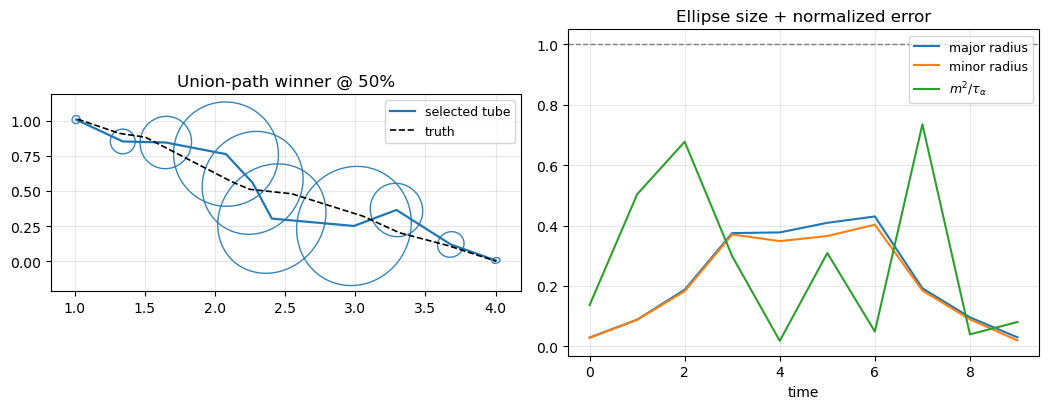

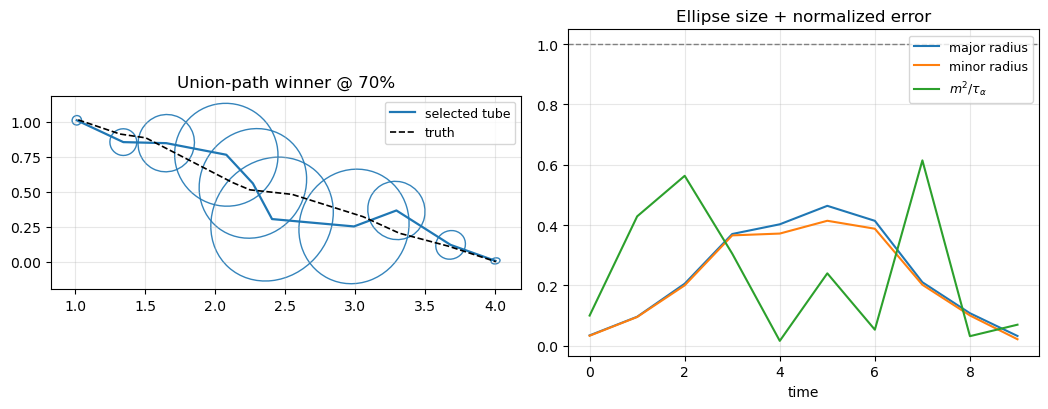

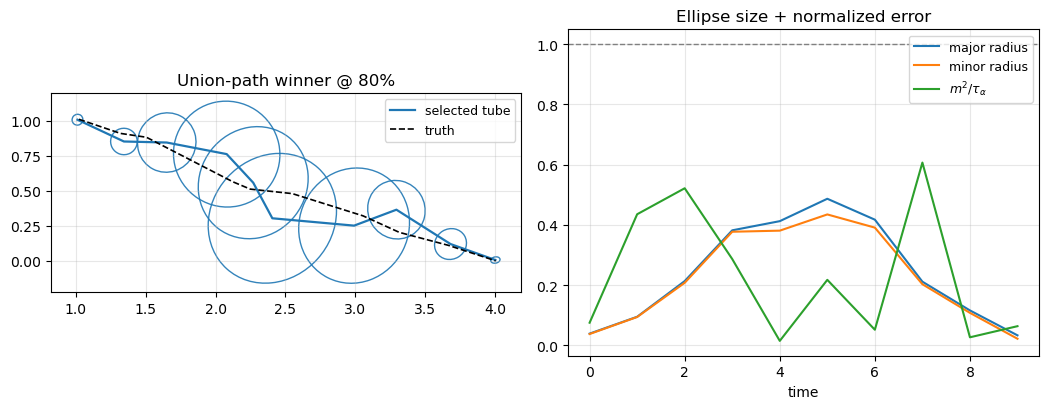

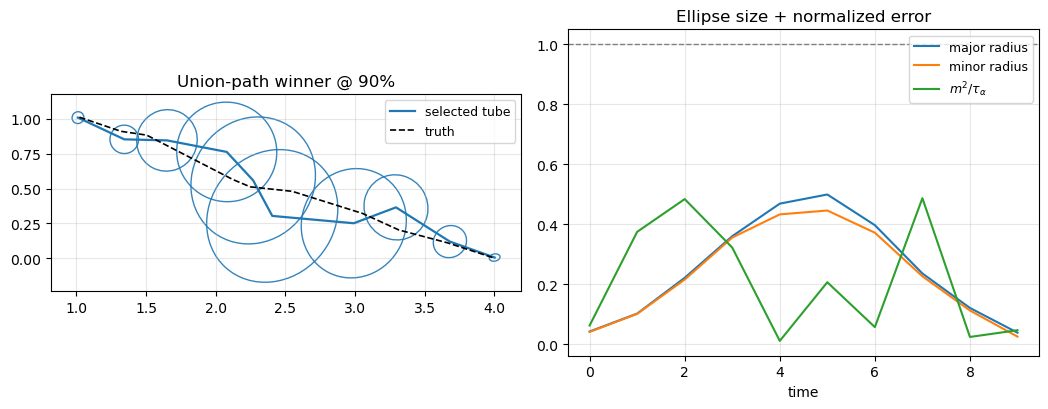

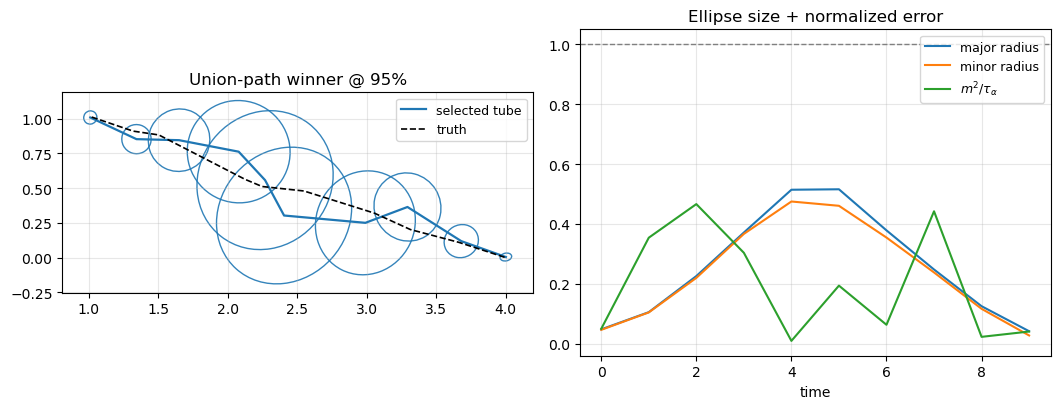

In [36]:
idx = np.random.randint(EVAL_SCENES)
for i, alp in enumerate(alphas_test):
    s_vec  = s_table[:, i]
    gamma0 = float(gamma_vec[i])
    plot_best_union_path_tube(
        head,
        Yp_eval[idx],            # (M, D)
        Yt_eval[idx],            # (D,)
        alpha=alp,
        s_vec=s_vec,
        gamma=gamma0,
        stride=max(1, T//6),     # ~6 ellipses total
        title=f"Union-path winner @ {int(100*alp)}%"
    )